In [38]:
import sys
from pathlib import Path

# Add repository root to Python path
repo_root = Path().absolute().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import ROOT
import matplotlib.pyplot as plt
import numpy as np
import os
import uproot
import awkward as ak



In [39]:
file = "/scratch/MINERvA/raw_data/MediumEnergy_FHC_StandardMC_Playlist/1A/MasterAnaDev_mc_AnaTuple_run00110000_Playlist.root"
#with uproot.open(file) as uf:
master_ana_dev = uproot.open(file)["MasterAnaDev"]


In [40]:
from dataclasses import dataclass
@dataclass
class DenseCollection:
    bounds: np.ndarray  # shape (n_events + 1,)
    data: np.ndarray    # shape (n_total_particles, n_features)
    n: np.ndarray       # shape (n_events,) - simply the one-difference of bounds
    keys: list = None
    column_widths: list = None


def get_dense(keys, master_ana_dev_frame):
    column_arrays = [master_ana_dev_frame[key].array() for key in keys]
    # Get number of particles per event from mc_part_arrays[0]
    n_per_event = ak.num(column_arrays[0])
    column_arrays = [ak.flatten(arr).to_numpy() for arr in column_arrays]
    column_widths = []
    for i in column_arrays:
        if len(i.shape) == 1:
            column_widths.append(1)
        else:
            column_widths.append(i.shape[1])
    # Now, put the mc_part_arrays in a dense matrix + make an index tensor where i and i+1 elements point to event boundaries of ith event
    matrix = np.zeros((len(column_arrays[0]), sum(column_widths)), dtype = np.float32)
    # Replace the nans with zeros
    start_idx = 0
    for i, arr in enumerate(column_arrays):
        if column_widths[i] == 1:
            matrix[:, start_idx] = arr
        else:
            matrix[:, start_idx:start_idx+column_widths[i]] = arr
        start_idx += column_widths[i]
    event_boundaries = np.zeros(len(n_per_event) + 1, dtype=np.int32)
    event_boundaries[1:] = np.cumsum(n_per_event)
    # swap nans in matrix with 0
    matrix[np.isnan(matrix)] = 0
    return DenseCollection(bounds=event_boundaries, data=matrix, n=n_per_event.to_numpy(), keys=keys, column_widths=column_widths)


In [41]:
def get_photons(master_ana_dev_frame):
    # slightly special treatment for gamma1 and gamma2
    gamma1_keys = ["gamma1_px", "gamma1_py", "gamma1_pz", "gamma1_E"]
    gamma2_keys = ["gamma2_px", "gamma2_py", "gamma2_pz", "gamma2_E"]
    
    # Get gamma1 and gamma2 arrays
    gamma_arrays_1 = [master_ana_dev_frame[key].array() for key in gamma1_keys]
    gamma_arrays_2 = [master_ana_dev_frame[key].array() for key in gamma2_keys]
    
    # Filter for valid photons (E > 1e-5)
    filter_1 = gamma_arrays_1[3] > 1e-5
    filter_2 = gamma_arrays_2[3] > 1e-5

    gamma_arrays_1 = [arr[filter_1].to_numpy() for arr in gamma_arrays_1]
    gamma_arrays_2 = [arr[filter_2].to_numpy() for arr in gamma_arrays_2]
    gamma_arrays_1 = np.stack(gamma_arrays_1).T
    gamma_arrays_2 = np.stack(gamma_arrays_2).T
    
    # Count photons per event
    n_gamma1_per_event = filter_1.to_numpy().astype(np.int32)
    n_gamma2_per_event = filter_2.to_numpy().astype(np.int32)
    n_per_event = n_gamma1_per_event + n_gamma2_per_event
    
    # Build photon data in event order
    photon_four_vectors = np.zeros((sum(n_per_event), 4), dtype=np.float32)
    current_idx = 0
    current_idx_gamma1 = 0
    current_idx_gamma2 = 0
    for i in range(len(n_per_event)):
        photon_four_vectors[current_idx:current_idx+n_gamma1_per_event[i], :] = gamma_arrays_1[current_idx_gamma1:current_idx_gamma1+n_gamma1_per_event[i]]
        current_idx += n_gamma1_per_event[i]
        # the line below fails, print debugging info - indices, ...
        photon_four_vectors[current_idx:current_idx+n_gamma2_per_event[i], :] = gamma_arrays_2[current_idx_gamma2:current_idx_gamma2+n_gamma2_per_event[i]]
        current_idx_gamma1 += n_gamma1_per_event[i]
        current_idx_gamma2 += n_gamma2_per_event[i]
        current_idx += n_gamma2_per_event[i]
    # Create event boundaries
    event_boundaries = np.zeros(len(n_per_event) + 1, dtype=np.int32)
    event_boundaries[1:] = np.cumsum(n_per_event)
    return DenseCollection(bounds=event_boundaries, data=photon_four_vectors, n=n_per_event, keys=gamma1_keys, column_widths=[1, 1, 1, 1])



In [42]:
def get_muons(master_ana_dev_frame, only_keep_minos_matched=True):
    # Slightly special treatment for muons
    muon_keys = ["muon_corrected_p", "muon_theta", "muon_phi", "muon_thetaX", "muon_thetaY", "muon_fuzz_energy", "muon_iso_blobs_energy", "MasterAnaDev_muon_E", "MasterAnaDev_muon_Px", "MasterAnaDev_muon_Py", "MasterAnaDev_muon_Pz"]
    # filter out cases where muon_corrected_p[:, 0] == -999 and muon_corrected_p[:, 1]] == -999
    muon_arrays = [master_ana_dev_frame[key].array() for key in muon_keys]
    if only_keep_minos_matched:
        mask = (muon_arrays[0][:, 0] != -999) & (muon_arrays[0][:, 1] != -999)
    else:
        #mask = master_ana_dev_frame["truth_reco_has_muon"].array()
        mask = np.ones(len(muon_arrays[0]), dtype=bool)
        mask = ak.from_numpy(mask)
    muon_arrays = [arr[mask].to_numpy() for arr in muon_arrays]
    # Exclude muons with abs of any component of any key > 1e6 - some weird anomalies
    n_muon_per_event = mask.to_numpy().astype(np.int32)
    # now put the muon_arrays in a dense matrix + make an index tensor where i and i+1 elements point to event boundaries of ith event
    muon_matrix = np.zeros((len(muon_arrays[0]), len(muon_keys)+3), dtype=np.float32)
    column_widths = [4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
    start_idx = 0
    for i, arr in enumerate(muon_arrays):
        if column_widths[i] == 1:
            muon_matrix[:, start_idx] = arr
        else:
            muon_matrix[:, start_idx:start_idx+column_widths[i]] = arr
        start_idx += column_widths[i]
    muon_event_boundaries = np.zeros(len(n_muon_per_event) + 1, dtype=np.int32)
    muon_event_boundaries[1:] = np.cumsum(n_muon_per_event)
    # Use: mc_part_event_boundaries and mc_part_matrix
    return DenseCollection(bounds=muon_event_boundaries, data=muon_matrix, n=n_muon_per_event, keys=muon_keys, column_widths=column_widths)

def remove_overflows(coll: DenseCollection):
    # Some entries in the data matrix are weird. Remove large numbers
    data_anomalies = np.where(np.abs(coll.data).max(axis=1) > 1e6)[0]
    data_anomalies_set = set(list(data_anomalies))
    n_per_event = coll.n.copy()
    data_filtered = np.delete(coll.data, data_anomalies, axis=0)
    event_bounds_old = coll.bounds
    # go through event bounds and create a new event bounds without the removed particles.
    #  shape of n_per_event should stay the same, just some events will have less (or 0) particles after removing.
    event_bounds_new = np.zeros(len(n_per_event) + 1, dtype=np.int32)
    n_per_event_new = np.zeros(len(n_per_event), dtype=np.int32)
    
    for event_idx in range(len(n_per_event)):
        # Get the particle indices for this event
        start_particle_idx = event_bounds_old[event_idx]
        end_particle_idx = event_bounds_old[event_idx + 1]
        
        # Count how many particles in this event are NOT anomalies
        n_removed = 0
        for particle_idx in range(start_particle_idx, end_particle_idx):
            if particle_idx in data_anomalies_set:
                n_removed += 1
        
        # Update the new particle count for this event
        n_per_event_new[event_idx] = n_per_event[event_idx] - n_removed
        # Update the event bounds
        event_bounds_new[event_idx + 1] = event_bounds_new[event_idx] + n_per_event_new[event_idx]
    
    return DenseCollection(bounds=event_bounds_new, data=data_filtered, n=n_per_event_new, keys=coll.keys, column_widths=coll.column_widths)


In [43]:
mc_part_keys = ["mc_FSPartPx", "mc_FSPartPy", "mc_FSPartPz", "mc_FSPartE", "mc_FSPartPDG"]
prong_keys = ["prong_part_pos", "prong_part_E", "prong_part_score", "prong_part_mass", "prong_part_charge", "prong_part_pid"]
blob_keys = ["MasterAnaDev_BlobX", "MasterAnaDev_BlobY", "MasterAnaDev_BlobZ", "MasterAnaDev_BlobT", "MasterAnaDev_BlobTPos", "MasterAnaDev_BlobTotalE"]

# This cell creates a compact gather of the observables easy to analyze both per event and all together over the whole dataset
mc_part = get_dense(mc_part_keys, master_ana_dev)
prong = get_dense(prong_keys, master_ana_dev)
blob = get_dense(blob_keys, master_ana_dev)
photons = get_photons(master_ana_dev)

In [44]:
photons.bounds[:10], photons.data[:5,  -1]

(array([0, 1, 1, 1, 1, 1, 3, 3, 3, 3], dtype=int32),
 array([  31.176472,  582.3584  ,   61.07716 , 1995.3672  ,   99.06528 ],
       dtype=float32))

In [45]:
master_ana_dev["gamma1_E"].array()[:5], master_ana_dev["gamma2_E"].array()[:5]

(<Array [0, -1e+04, -1e+04, -1e+04, -1e+04] type='5 * float64'>,
 <Array [31.2, -1e+04, -1e+04, -1e+04, -1e+04] type='5 * float64'>)

In [46]:
muon = get_muons(master_ana_dev, only_keep_minos_matched=True)
muon_all = get_muons(master_ana_dev, only_keep_minos_matched=False)
muon = remove_overflows(muon)
muon_all = remove_overflows(muon_all)

In [47]:
(prong.data[:, 7] >=0).all()

True

In [48]:
muon_all.n.mean(), muon.n.mean()

(0.9997908162991649, 0.7050241633992888)

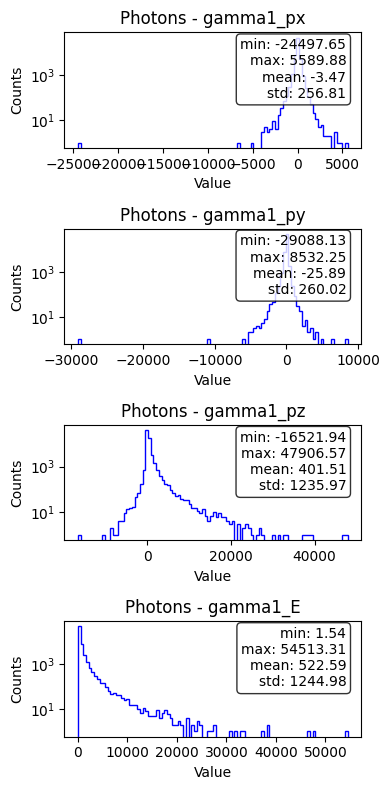

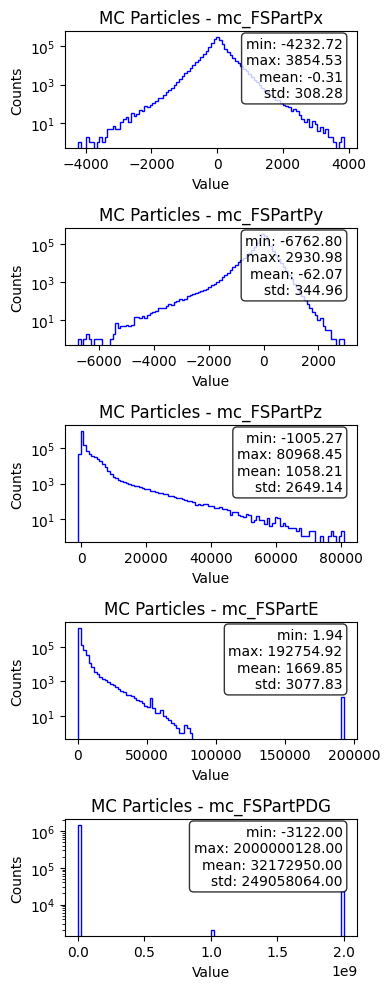

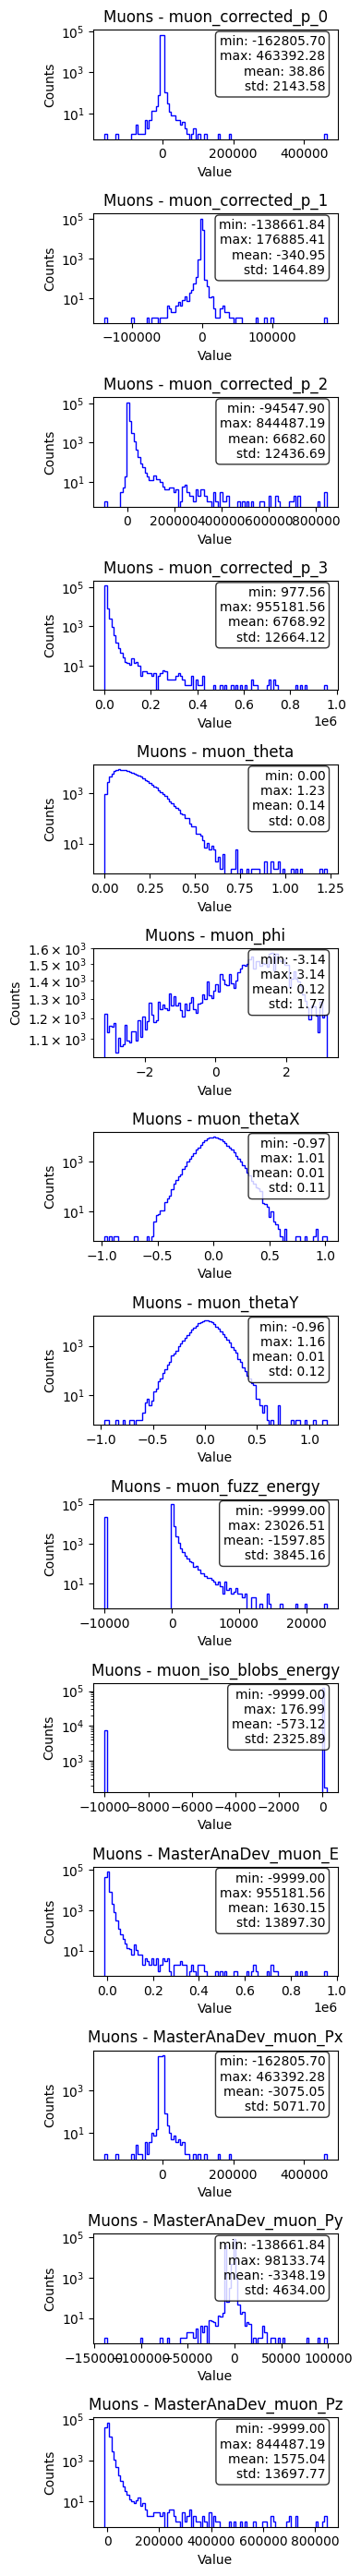

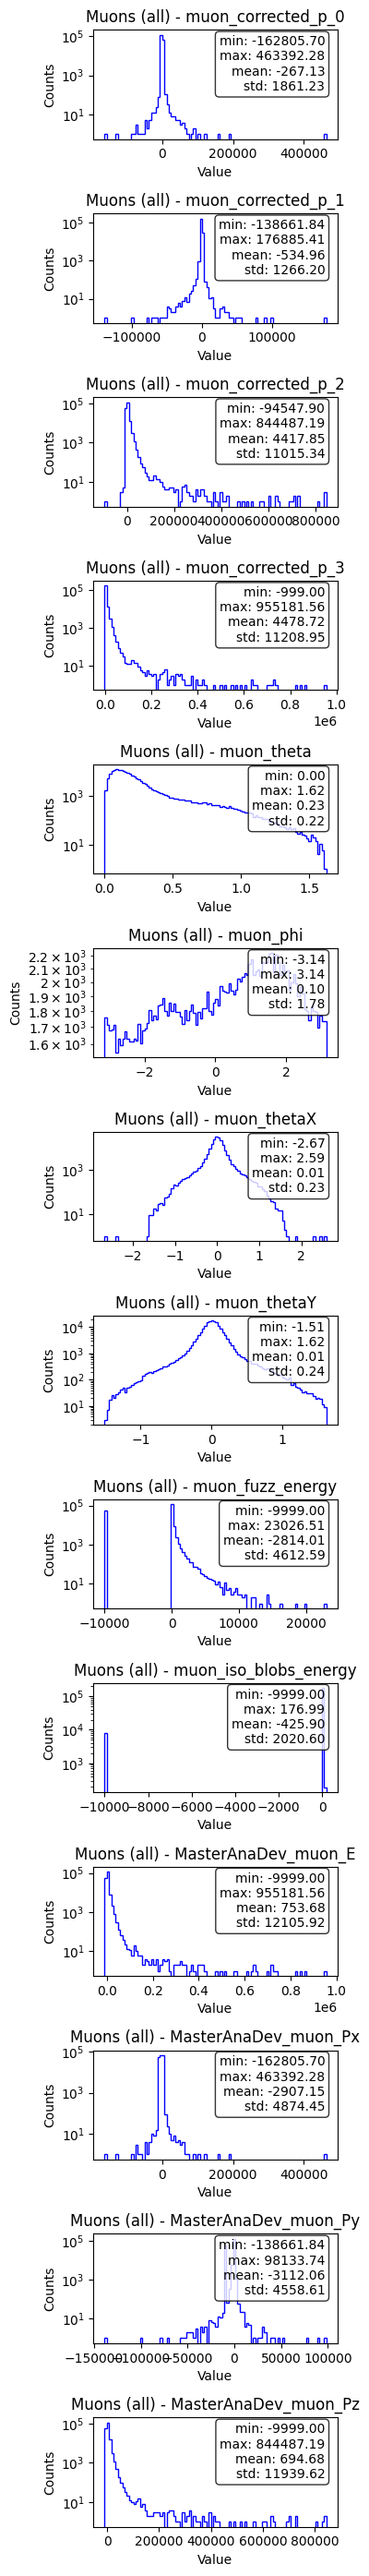

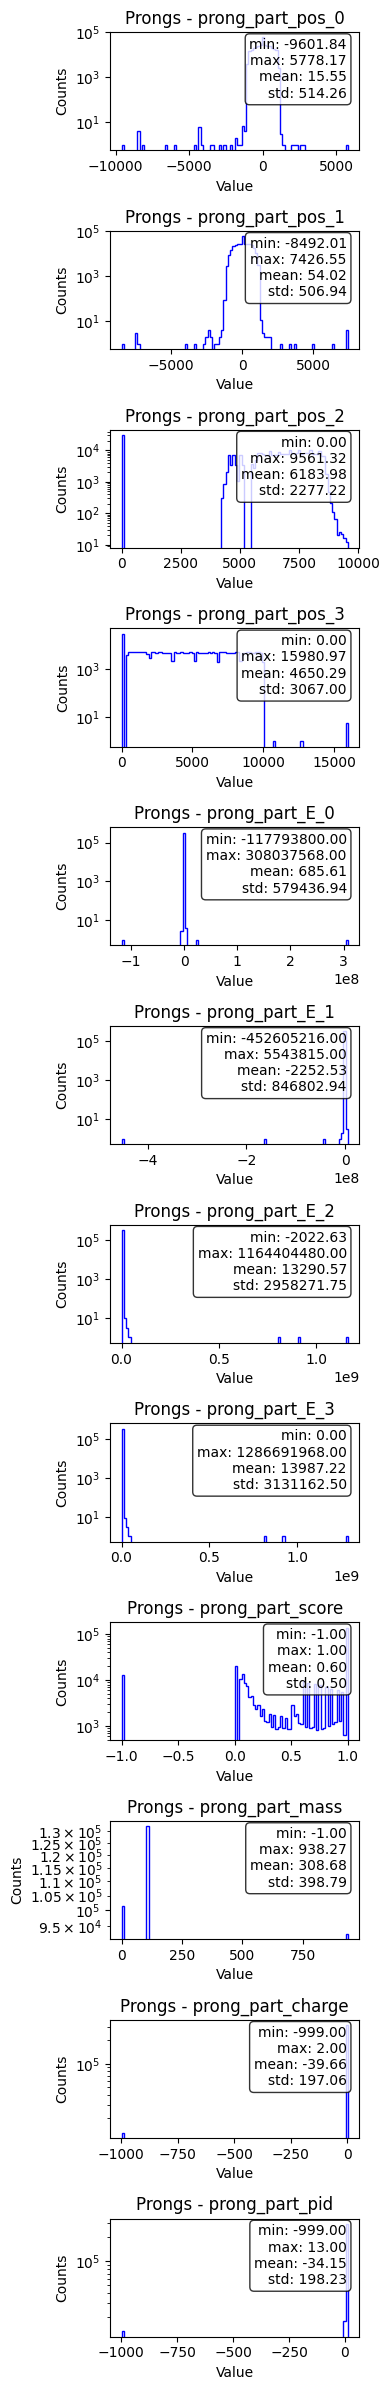

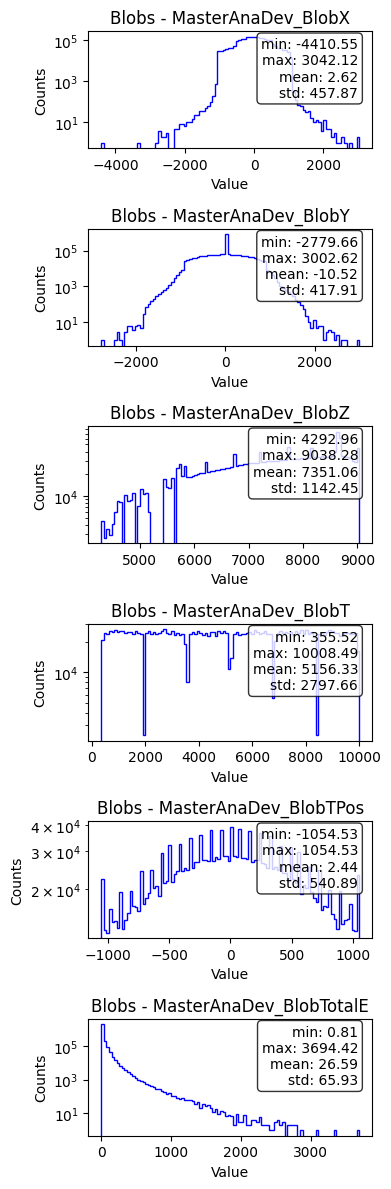

In [49]:
# Muon, MC_part, prong, and blob, make compact histograms of all the column values (all in one figure but separate plots stacked on top of each other).
# If column width > 1, make just a plot of the first component.
# Include some summary statistics (min, max, mean, std), and print them on the plots too. Make a separate figure for each of the four collections.

def plot_collection(collection: DenseCollection, collection_name: str, output_file: str = None):
    n_columns = len(collection.data[0])
    column_names = []
    for i in range(len(collection.keys)):
        if collection.column_widths[i] == 1:
            column_names.append(collection.keys[i])
        else:
            for j in range(collection.column_widths[i]):
                column_names.append(f"{collection.keys[i]}_{j}")
    fig, axes = plt.subplots(n_columns, 1, figsize=(4, 2 * n_columns))
    if n_columns == 1:
        axes = [axes]
    for i in range(n_columns):
        data_column = collection.data[:,i]
        # get column name + component (if applicable)
        column_name = column_names[i]
        axes[i].hist(data_column, bins=100, histtype='step', color='blue')
        axes[i].set_title(f"{collection_name} - {column_name}")
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Counts")
        axes[i].set_yscale("log")
        # compute summary statistics
        col_min = np.min(data_column)
        if np.isnan(col_min):
            # print the data column if its nan
            print(f"Column {column_name} contains NaN values:", data_column)
            print("N of nan vals: ", np.isnan(data_column).sum())
        col_max = np.max(data_column)
        col_mean = np.mean(data_column)
        col_std = np.std(data_column)
        stats_text = f"min: {col_min:.2f}\nmax: {col_max:.2f}\nmean: {col_mean:.2f}\nstd: {col_std:.2f}"
        axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes,
                     verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    fig.tight_layout()
    if output_file:
        fig.savefig(output_file)
    else:
        fig.show()

plot_collection(photons, "Photons", "out/photons_stats.pdf")
plot_collection(mc_part, "MC Particles", "out/mc_part_stats.pdf")
plot_collection(muon, "Muons", "out/muon_stats.pdf")
plot_collection(muon_all, "Muons (all)", "out/muon_all_stats.pdf")
plot_collection(prong, "Prongs", "out/prong_stats.pdf")
plot_collection(blob, "Blobs", "out/blob_stats.pdf")


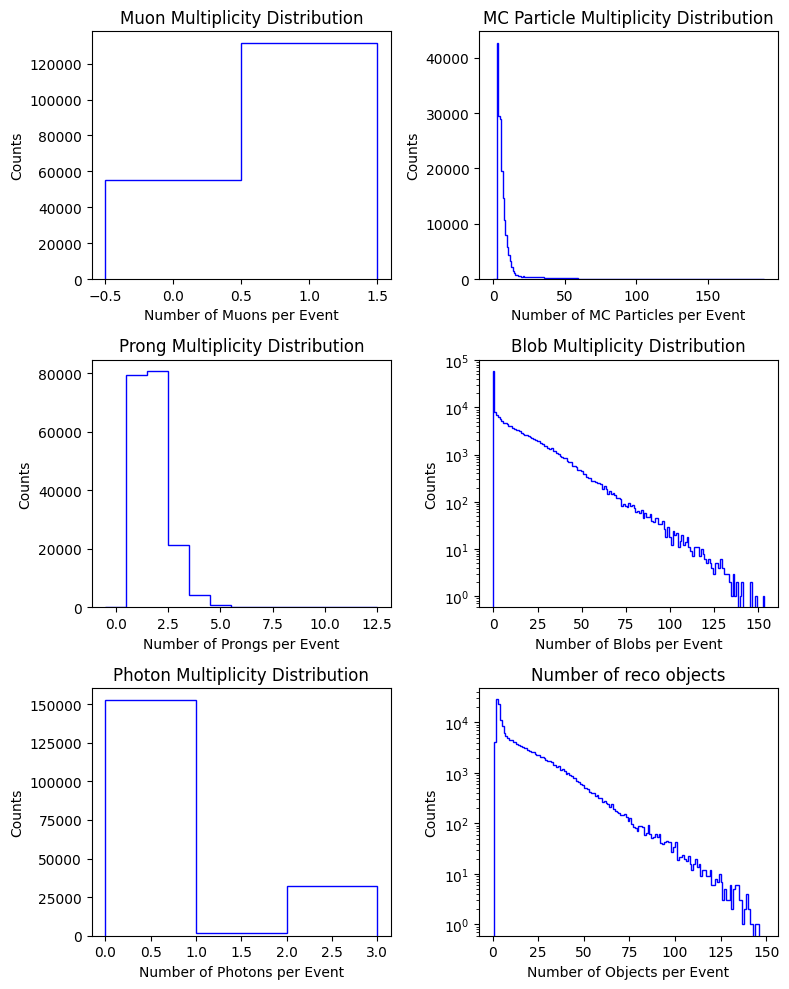

In [50]:
# Plot histograms - distributions of N muons, M MC particles, N prongs, and N blobs per event.
fig, ax = plt.subplots(3, 2, figsize=(8, 10))
bins_muon = [0, 1, 2]
ax[0, 0].hist(muon.n, bins=bins_muon, histtype='step', color='blue', align='left', rwidth=0.5, label="only with p_corrected")
#ax[0, 0].hist(muon_all.n, bins=bins_muon, histtype='step', color='red', align='left', rwidth=0.5, label="all")
ax[0, 0].set_xlabel("Number of Muons per Event")
ax[0, 0].set_ylabel("Counts")
ax[0, 0].set_title("Muon Multiplicity Distribution")
#ax[0, 0].legend()
bins_mc_part = np.arange(0, np.max(mc_part.n) + 2) - 0.5
ax[0, 1].hist(mc_part.n, bins=bins_mc_part, histtype='step', color='blue')
ax[0, 1].set_xlabel("Number of MC Particles per Event")
ax[0, 1].set_ylabel("Counts")
ax[0, 1].set_title("MC Particle Multiplicity Distribution")
bins_prong = np.arange(0, np.max(prong.n) + 2) - 0.5
ax[1, 0].hist(prong.n, bins=bins_prong, histtype='step', color='blue')
ax[1, 0].set_xlabel("Number of Prongs per Event")
ax[1, 0].set_ylabel("Counts")
ax[1, 0].set_title("Prong Multiplicity Distribution")
bins_blob = np.arange(0, np.max(blob.n) + 2) - 0.5
ax[1, 1].hist(blob.n, bins=bins_blob, histtype='step', color='blue')
ax[1, 1].set_xlabel("Number of Blobs per Event")
ax[1, 1].set_ylabel("Counts")
ax[1, 1].set_title("Blob Multiplicity Distribution")
ax[1, 1].set_yscale("log")

bins_photon = [0, 1, 2, 3]
ax[2, 0].hist(photons.n, bins=bins_photon, histtype='step', color='blue')
ax[2, 0].set_xlabel("Number of Photons per Event")
ax[2, 0].set_ylabel("Counts")
ax[2, 0].set_title("Photon Multiplicity Distribution")

n_blobs = blob.n
n_prongs = prong.n
n_muons = muon.n
n_photons = photons.n
n_objects = n_blobs + n_prongs + n_muons + n_photons
bins_objects = np.arange(0, 150, 1)

ax[2, 1].hist(n_objects, bins=bins_objects, histtype='step', color='blue')
ax[2, 1].set_xlabel("Number of Objects per Event")
ax[2, 1].set_ylabel("Counts")
ax[2, 1].set_title("Number of reco objects")
ax[2, 1].set_yscale("log")
fig.tight_layout()
fig.savefig("out/multiplicity_distributions.pdf")
fig.show()


In [51]:
np.unique(photons.n, return_counts=True)

(array([0, 1, 2], dtype=int32), array([152831,   1592,  32016]))

In [52]:
# Print statistics for the multiplicities of MC particles, prongs, blobs, muons (min, max, mean)
print(f"MC Particles: Min multiplicity: {np.min(mc_part.n)}, Max multiplicity: {np.max(mc_part.n)}, Mean multiplicity: {np.mean(mc_part.n)}")
print(f"Prongs: Min multiplicity: {np.min(prong.n)}, Max multiplicity: {np.max(prong.n)}, Mean multiplicity: {np.mean(prong.n)}")
print(f"Blobs: Min multiplicity: {np.min(blob.n)}, Max multiplicity: {np.max(blob.n)}, Mean multiplicity: {np.mean(blob.n)}")
print(f"Muons: Min multiplicity: {np.min(muon.n)}, Max multiplicity: {np.max(muon.n)}, Mean multiplicity: {np.mean(muon.n)}")
print(f"Muons (all): Min multiplicity: {np.min(muon_all.n)}, Max multiplicity: {np.max(muon_all.n)}, Mean multiplicity: {np.mean(muon_all.n)}")

MC Particles: Min multiplicity: 2, Max multiplicity: 189, Mean multiplicity: 8.23340073697027
Prongs: Min multiplicity: 1, Max multiplicity: 12, Mean multiplicity: 1.7487811026662876
Blobs: Min multiplicity: 0, Max multiplicity: 153, Mean multiplicity: 12.451482790617844
Muons: Min multiplicity: 0, Max multiplicity: 1, Mean multiplicity: 0.7050241633992888
Muons (all): Min multiplicity: 0, Max multiplicity: 1, Mean multiplicity: 0.9997908162991649


In [53]:
# print % with zero multiplicity for each of the collections
print("Percentage of events with zero multiplicity:")
print(f"MC Particles: {np.sum(mc_part.n == 0) / len(mc_part.n)}")
print(f"Prongs: {np.sum(prong.n == 0) / len(prong.n)}")
print(f"Blobs: {np.sum(blob.n == 0) / len(blob.n)}")
print(f"Muons: {np.sum(muon.n == 0) / len(muon.n)}")
print(f"Muons (all): {np.sum(muon_all.n == 0) / len(muon_all.n)}")



Percentage of events with zero multiplicity:
MC Particles: 0.0
Prongs: 0.0
Blobs: 0.3172619462666073
Muons: 0.29497583660071125
Muons (all): 0.0002091837008351257


In [54]:
E_nu_MC = master_ana_dev["mc_incomingE"].array().to_numpy()
MC_current = master_ana_dev["mc_current"].array().to_numpy() # 1=CC, 2=NC

# From the CCQE formula purely from the reconstructed muon:
E_nu_from_formula = np.zeros(len(muon.n))
Emu = muon.data[:, 3]
E_muon_per_event = np.zeros(len(muon.n))
pmu = np.linalg.norm(muon.data[:, 0:3], axis=1)
mu_theta_cos = muon.data[:, 2] / np.linalg.norm(muon.data[:, 0:3], axis=1)
proton_mass = 938.2720813505859
muon_mass = 105.6583745
E_nu_formula = (2 * proton_mass * Emu - muon_mass * muon_mass) / (2 * (proton_mass - Emu + pmu * mu_theta_cos))
# Make a mask - only keep mu_theta < 20 degrees and |p| between 1.5 and 20 GeV
mask_muon = (mu_theta_cos > np.cos(20 * np.pi / 180)) & (pmu > 1.5*1000) & (pmu < 20*1000)
mask_muon_per_event = np.zeros(len(muon.n)) # whether the event passes the filtering criteria - muon within a specific range
mu_idx = 0
for i in range(len(muon.n)):
    if muon.n[i] > 0:
        #if mask_muon[mu_idx]:
        E_nu_from_formula[i] = E_nu_formula[mu_idx]
        E_muon_per_event[i] = Emu[mu_idx]
        mask_muon_per_event[i] = mask_muon[mu_idx]
        #else:
        #    E_nu_from_formula[i] = -1
        mu_idx += 1
    else:
        E_nu_from_formula[i] = -1
        E_muon_per_event[i] = -1
#E_nu_from_formula[~mask_muon] = -1

# From the dataframe:
E_nu_from_df = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy()
E_nu_from_p_correction = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy()
E_nu_from_p_correction[E_nu_from_p_correction < 0] = 0
invalid_idx = np.where(E_nu_from_df < 0)[0]
E_nu_from_df[invalid_idx] = -1
E_nu_from_df_with_p_correction = E_nu_from_df + E_nu_from_p_correction
E_nu_from_df_with_p_correction[invalid_idx] = -1


In [55]:
def get_Enu_fig(mc_E, reco_e_dict: dict):
    # reco_e_dict: key should be what's plotted. value should be same shape as mc_E, if it's not reconstructed, it should have value -1.
    # fig should have 2 x 2 subplots. left: counts; right: normalized histograms to unit area.
    # Top: E / 1000 histograms (GeV); Bottom: E_reco/E_mc
    fig, ax = plt.subplots(2, 2, figsize=(12, 12))
    #fig_eff, ax_eff = plt.subplots(figsize=(5, 5)) # eff. vs mc_E plots
    #mc_E_bins_efficiency = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20] # for efficiency
    bins_E = np.linspace(0, 20, 200)
    bins_E_reco_over_true = np.linspace(0, 2, 100)
    ax[0, 0].hist(mc_E / 1000, bins=bins_E, histtype='step', color='black', label='MC E')
    ax[0, 1].hist(mc_E / 1000, bins=bins_E, histtype='step', color='black', label='MC E', density=True)
    for method in reco_e_dict.keys():
        mask = reco_e_dict[method] > 0
        percentage_reconstructed = round(np.sum(mask) / len(mask) * 100, 1)
        ax[0, 0].hist(reco_e_dict[method] / 1000, bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)")
        ax[0, 1].hist(reco_e_dict[method] / 1000, bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)", density=True)
        E_reco_over_true = reco_e_dict[method][mask] / mc_E[mask]
        ax[1, 0].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=method + f" ({percentage_reconstructed}%)")
        ax[1, 1].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=method + f" ({percentage_reconstructed}%)", density=True)
    ax[0, 0].legend()
    ax[0, 0].set_xlabel("Energy [GeV]")
    ax[0, 0].set_ylabel("Counts")
    ax[0, 0].set_title("E nu Distribution")
    ax[0, 1].legend()
    ax[0, 1].set_xlabel("Energy [GeV]")
    ax[0, 1].set_ylabel("Relative counts")
    ax[0, 1].set_title("E nu Distribution (normalized)")
    ax[1, 0].legend()
    ax[1, 0].set_xlabel("E reco / E true")
    ax[1, 0].set_ylabel("Counts")
    ax[1, 0].set_title("E reco / E true Distribution")
    ax[1, 1].legend()
    ax[1, 1].set_xlabel("E reco / E true")
    ax[1, 1].set_ylabel("Relative counts")
    ax[1, 1].set_title("E reco / E true Distribution (normalized)")
    # Put a grid on all
    ax[0, 0].grid(True)
    ax[0, 1].grid(True)
    ax[1, 0].grid(True)
    ax[1, 1].grid(True)

    # put legendson bottom right
    ax[0, 0].legend(loc='lower right')
    ax[0, 1].legend(loc='lower right')
    ax[1, 0].legend(loc='lower right')
    ax[1, 1].legend(loc='lower right')
    fig.tight_layout()
    return fig


In [56]:
results = {"CCQE formula": E_nu_from_formula, "Enu_from_muon": E_nu_from_df, "Enu_from_muon+proton": E_nu_from_df_with_p_correction}

In [57]:
E_recoil = master_ana_dev['MasterAnaDev_hadron_recoil'].array().to_numpy()
E_recoil = np.where(E_recoil >= 0, E_recoil, -1)
E_recoil_CCinc = master_ana_dev['MasterAnaDev_hadron_recoil_CCInc'].array().to_numpy()
E_recoil_CCinc = np.where(E_recoil_CCinc >= 0, E_recoil_CCinc, -1)

invalid_muon = E_muon_per_event == -1
invalid_E_recoil = E_recoil == -1
invalid_E_recoil_CCinc = E_recoil_CCinc == -1

results["E_mu+E_recoil"] = E_muon_per_event + E_recoil
results["E_mu+E_recoil_CCinc"] = E_muon_per_event + E_recoil_CCinc

results["E_mu+E_recoil"][invalid_muon | invalid_E_recoil] = -1
results["E_mu+E_recoil_CCinc"][invalid_muon | invalid_E_recoil_CCinc] = -1


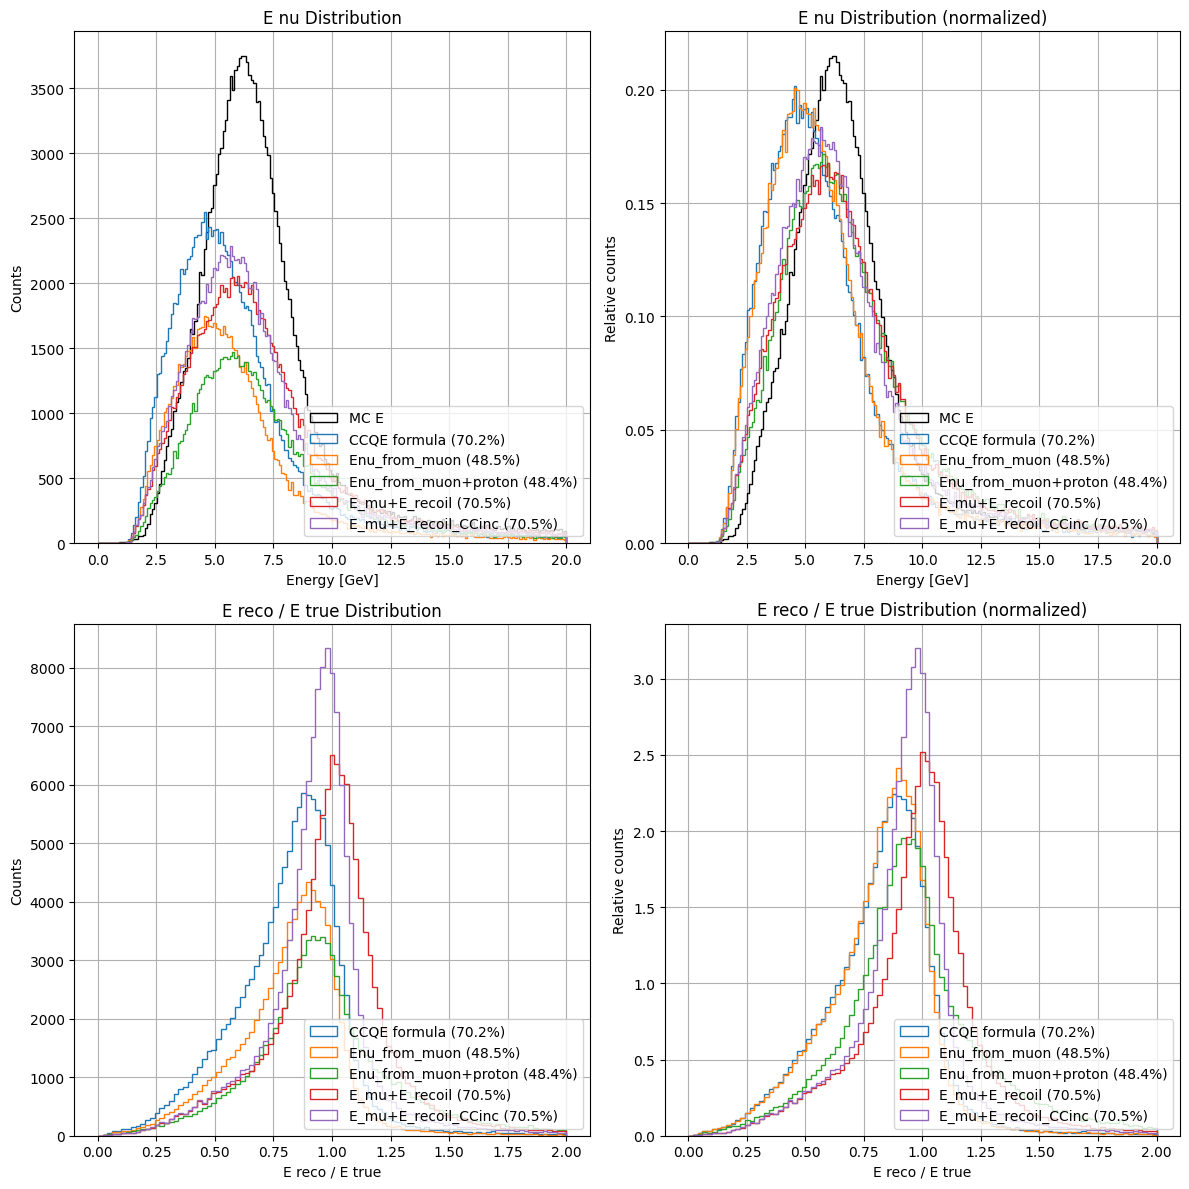

In [58]:
get_Enu_fig(E_nu_MC, results).show()

In [59]:
# Load interaction type information
mc_intType = master_ana_dev["mc_intType"].array().to_numpy()
mc_w = master_ana_dev["mc_w"].array().to_numpy()  # invariant mass in MeV
mc_resID = master_ana_dev["mc_resID"].array().to_numpy()

# Create masks for different processes
mask_CCQE = mc_intType == 1
mask_RES = mc_intType == 2  # Resonance/Delta
mask_DIS = mc_intType == 3
mask_2p2h = (mc_intType == 8) | (mc_intType == 10)  # MEC/2p2h
mask_coherent = mc_intType == 4
mask_other = ~(mask_CCQE | mask_RES | mask_DIS | mask_2p2h | mask_coherent)

# Print statistics
print(f"CCQE: {mask_CCQE.sum()} events ({100*mask_CCQE.sum()/len(mc_intType):.1f}%)")
print(f"Resonance: {mask_RES.sum()} events ({100*mask_RES.sum()/len(mc_intType):.1f}%)")
print(f"DIS: {mask_DIS.sum()} events ({100*mask_DIS.sum()/len(mc_intType):.1f}%)")
print(f"2p2h/MEC: {mask_2p2h.sum()} events ({100*mask_2p2h.sum()/len(mc_intType):.1f}%)")
print(f"Coherent: {mask_coherent.sum()} events ({100*mask_coherent.sum()/len(mc_intType):.1f}%)")
print(f"Other: {mask_other.sum()} events ({100*mask_other.sum()/len(mc_intType):.1f}%)")

# Also check W distribution
W_GeV = mc_w / 1000
print(f"\nW statistics:")
print(f"  W < 1.3 GeV (QE region): {(W_GeV < 1.3).sum()} events ({100*(W_GeV < 1.3).sum()/len(W_GeV):.1f}%)")
print(f"  1.3 < W < 2.0 GeV (RES region): {((W_GeV >= 1.3) & (W_GeV < 2.0)).sum()} events ({100*((W_GeV >= 1.3) & (W_GeV < 2.0)).sum()/len(W_GeV):.1f}%)")
print(f"  W > 2.0 GeV (DIS region): {(W_GeV >= 2.0).sum()} events ({100*(W_GeV >= 2.0).sum()/len(W_GeV):.1f}%)")

CCQE: 23031 events (12.4%)
Resonance: 40132 events (21.5%)
DIS: 114574 events (61.5%)
2p2h/MEC: 6737 events (3.6%)
Coherent: 1948 events (1.0%)
Other: 17 events (0.0%)

W statistics:
  W < 1.3 GeV (QE region): 45320 events (24.3%)
  1.3 < W < 2.0 GeV (RES region): 57297 events (30.7%)
  W > 2.0 GeV (DIS region): 83822 events (45.0%)


IndexError: index 4 is out of bounds for axis 0 with size 4

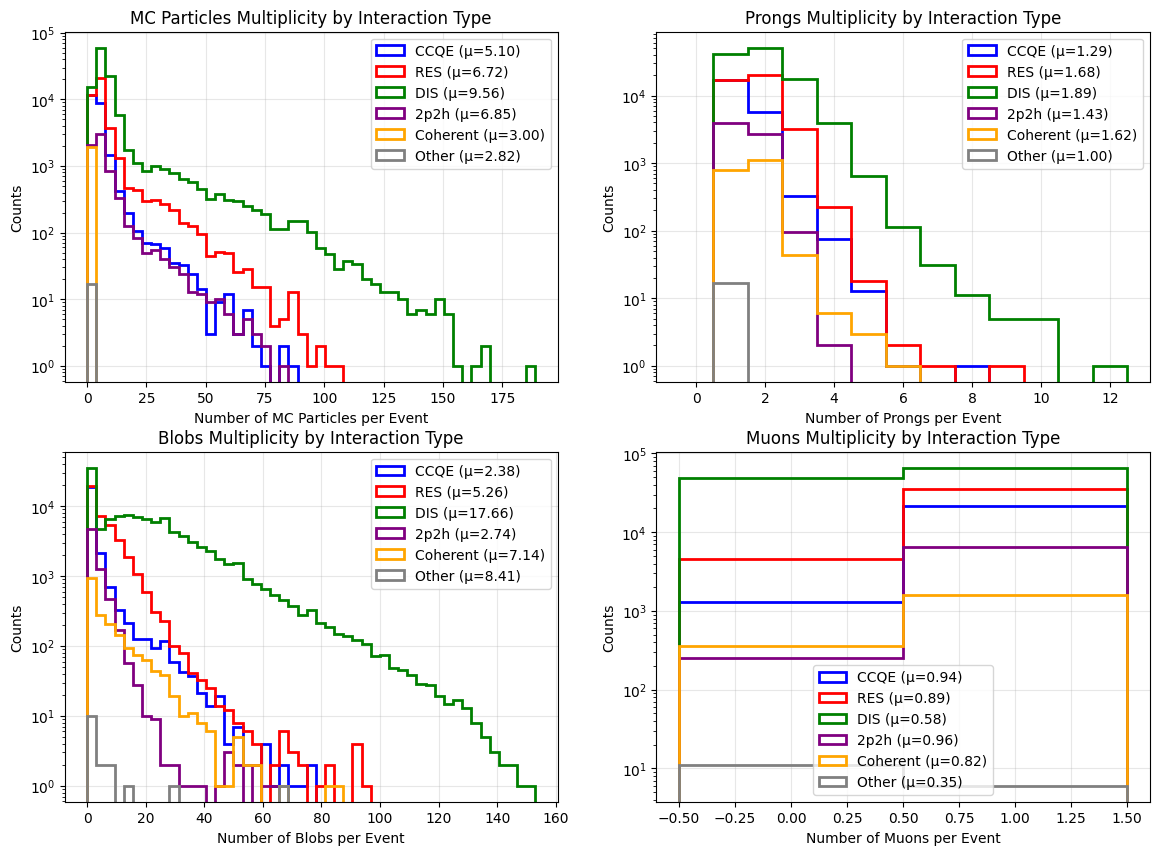

In [60]:
# Plot multiplicities by interaction type
def plot_multiplicities_by_inttype(collections_dict, masks_dict, output_file=None):
    """
    Plot multiplicity distributions separated by interaction type.
    
    collections_dict: dict with keys like 'MC Particles', 'Prongs', etc. and values are DenseCollection objects
    masks_dict: dict with keys like 'CCQE', 'RES', etc. and values are boolean masks
    """
    n_collections = len(collections_dict)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    colors = {
        'CCQE': 'blue',
        'RES': 'red',
        'DIS': 'green',
        '2p2h': 'purple',
        'Coherent': 'orange',
        'Other': 'gray'
    }
    
    for idx, (coll_name, coll) in enumerate(collections_dict.items()):
        ax = axes[idx]
        
        # Determine bins based on the collection
        max_n = np.max(coll.n)
        if max_n > 50:
            bins = np.linspace(0, max_n, 50)
        else:
            bins = np.arange(0, max_n + 2) - 0.5
        
        # Plot each interaction type
        for int_type, mask in masks_dict.items():
            multiplicity_subset = coll.n[mask]
            ax.hist(multiplicity_subset, bins=bins, histtype='step', 
                   color=colors[int_type], label=f'{int_type} (μ={multiplicity_subset.mean():.2f})',
                   linewidth=2)
        
        ax.set_xlabel(f"Number of {coll_name} per Event")
        ax.set_ylabel("Counts")
        ax.set_title(f"{coll_name} Multiplicity by Interaction Type")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')
    
    fig.tight_layout()
    if output_file:
        fig.savefig(output_file)
    return fig

# Prepare the data
collections_dict = {
    'MC Particles': mc_part,
    'Prongs': prong,
    'Blobs': blob,
    'Muons': muon,
    "Photons": photons
}

masks_dict = {
    'CCQE': mask_CCQE,
    'RES': mask_RES,
    'DIS': mask_DIS,
    '2p2h': mask_2p2h,
    'Coherent': mask_coherent,
    'Other': mask_other
}

fig = plot_multiplicities_by_inttype(collections_dict, masks_dict, output_file="out/multiplicities_by_inttype.pdf")


IndexError: index 4 is out of bounds for axis 0 with size 4

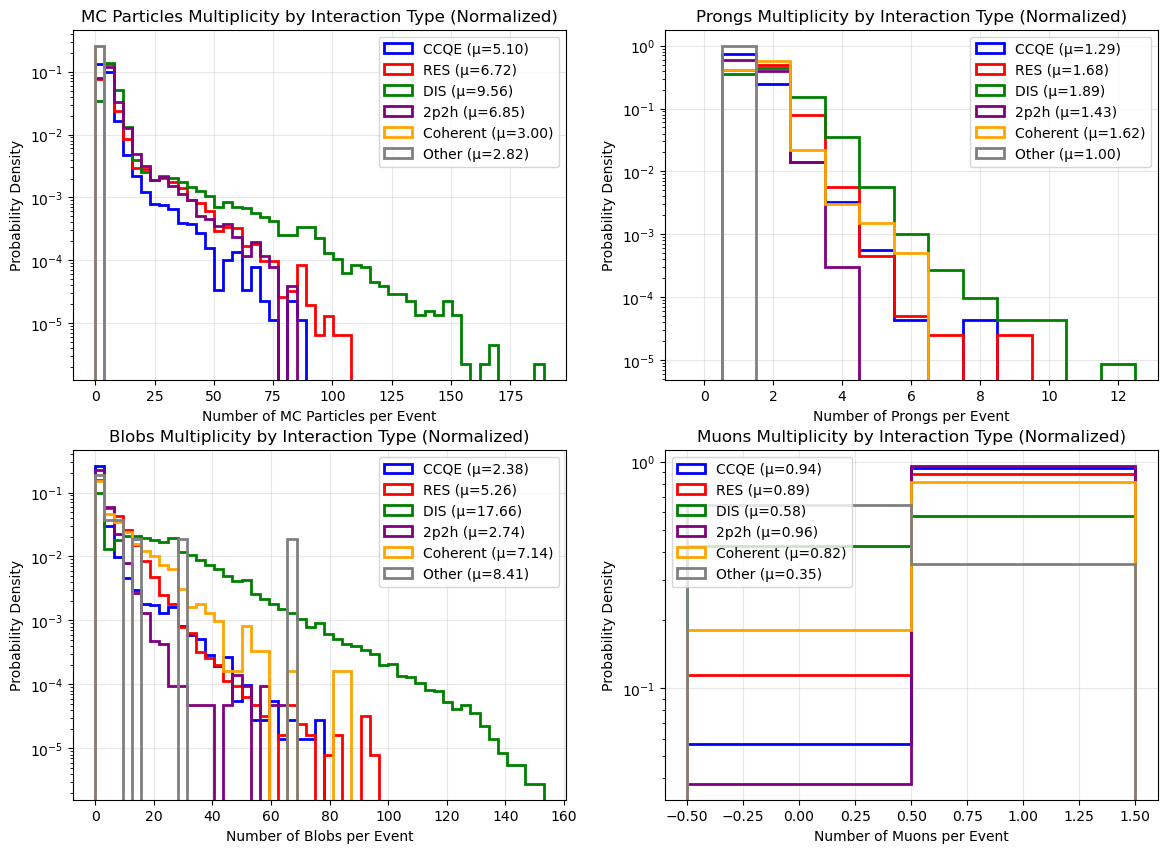

: 

In [ ]:
# Create normalized versions to see shapes better
def plot_multiplicities_by_inttype_normalized(collections_dict, masks_dict, output_file=None):
    """
    Plot normalized multiplicity distributions separated by interaction type.
    """
    n_collections = len(collections_dict)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    colors = {
        'CCQE': 'blue',
        'RES': 'red',
        'DIS': 'green',
        '2p2h': 'purple',
        'Coherent': 'orange',
        'Other': 'gray'
    }
    
    for idx, (coll_name, coll) in enumerate(collections_dict.items()):
        ax = axes[idx]
        
        # Determine bins based on the collection
        max_n = np.max(coll.n)
        if max_n > 50:
            bins = np.linspace(0, max_n, 50)
        else:
            bins = np.arange(0, max_n + 2) - 0.5
        
        # Plot each interaction type (normalized)
        for int_type, mask in masks_dict.items():
            multiplicity_subset = coll.n[mask]
            if len(multiplicity_subset) > 0:
                ax.hist(multiplicity_subset, bins=bins, histtype='step', 
                       color=colors[int_type], label=f'{int_type} (μ={multiplicity_subset.mean():.2f})',
                       linewidth=2, density=True)
        
        ax.set_xlabel(f"Number of {coll_name} per Event")
        ax.set_ylabel("Probability Density")
        ax.set_title(f"{coll_name} Multiplicity by Interaction Type (Normalized)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        # also log y axis
        ax.set_yscale('log')
    
    fig.tight_layout()
    if output_file:
        fig.savefig(output_file)
    return fig

fig_norm = plot_multiplicities_by_inttype_normalized(collections_dict, masks_dict, 
                                                      output_file="out/multiplicities_by_inttype_normalized.pdf")
plt.show()

In [61]:
# Print detailed statistics for each interaction type
print("=" * 80)
print("MULTIPLICITY STATISTICS BY INTERACTION TYPE")
print("=" * 80)

for int_type, mask in masks_dict.items():
    n_events = mask.sum()
    if n_events == 0:
        continue
    
    print(f"\n{int_type} ({n_events} events, {100*n_events/len(mask):.1f}%):")
    print("-" * 60)
    
    for coll_name, coll in collections_dict.items():
        mult = coll.n[mask]
        print(f"  {coll_name:15s}: mean={mult.mean():.2f}, std={mult.std():.2f}, "
              f"min={mult.min()}, max={mult.max()}, median={np.median(mult):.1f}")

MULTIPLICITY STATISTICS BY INTERACTION TYPE

CCQE (23031 events, 12.4%):
------------------------------------------------------------
  MC Particles   : mean=5.10, std=4.87, min=2, max=85, median=3.0
  Prongs         : mean=1.29, std=0.51, min=1, max=8, median=1.0
  Blobs          : mean=2.38, std=5.20, min=0, max=78, median=1.0
  Muons          : mean=0.94, std=0.23, min=0, max=1, median=1.0
  Photons        : mean=0.04, std=0.27, min=0, max=2, median=0.0

RES (40132 events, 21.5%):
------------------------------------------------------------
  MC Particles   : mean=6.72, std=7.86, min=3, max=106, median=4.0
  Prongs         : mean=1.68, std=0.65, min=1, max=9, median=2.0
  Blobs          : mean=5.26, std=6.35, min=0, max=94, median=4.0
  Muons          : mean=0.89, std=0.32, min=0, max=1, median=1.0
  Photons        : mean=0.11, std=0.45, min=0, max=2, median=0.0

DIS (114574 events, 61.5%):
------------------------------------------------------------
  MC Particles   : mean=9.56, st

In [ ]:
# Check photon mass consistency for gamma1 and gamma2
# For a photon: E^2 = p^2 (mass = 0), so E^2 - p^2 should be ~0

# Load gamma data
gamma1_px = master_ana_dev["gamma1_px"].array().to_numpy()
gamma1_py = master_ana_dev["gamma1_py"].array().to_numpy()
gamma1_pz = master_ana_dev["gamma1_pz"].array().to_numpy()
gamma1_E = master_ana_dev["gamma1_E"].array().to_numpy()

gamma2_px = master_ana_dev["gamma2_px"].array().to_numpy()
gamma2_py = master_ana_dev["gamma2_py"].array().to_numpy()
gamma2_pz = master_ana_dev["gamma2_pz"].array().to_numpy()
gamma2_E = master_ana_dev["gamma2_E"].array().to_numpy()

# Calculate momentum magnitude
gamma1_p = np.sqrt(gamma1_px**2 + gamma1_py**2 + gamma1_pz**2)
gamma2_p = np.sqrt(gamma2_px**2 + gamma2_py**2 + gamma2_pz**2)

# Calculate invariant mass squared: m^2 = E^2 - p^2
gamma1_m2 = gamma1_E**2 - gamma1_p**2
gamma2_m2 = gamma2_E**2 - gamma2_p**2

# Filter out invalid entries (E < 0 typically means not reconstructed)
valid_gamma1 = gamma1_E > 0
valid_gamma2 = gamma2_E > 0

print(f"Gamma 1 statistics ({valid_gamma1.sum()} valid events):")
print(f"  E: mean={gamma1_E[valid_gamma1].mean():.2f}, std={gamma1_E[valid_gamma1].std():.2f}")
print(f"  p: mean={gamma1_p[valid_gamma1].mean():.2f}, std={gamma1_p[valid_gamma1].std():.2f}")
print(f"  m^2: mean={gamma1_m2[valid_gamma1].mean():.2f}, std={gamma1_m2[valid_gamma1].std():.2f}")
print(f"  m: mean={np.sqrt(np.abs(gamma1_m2[valid_gamma1])).mean():.2f}")

print(f"\nGamma 2 statistics ({valid_gamma2.sum()} valid events):")
print(f"  E: mean={gamma2_E[valid_gamma2].mean():.2f}, std={gamma2_E[valid_gamma2].std():.2f}")
print(f"  p: mean={gamma2_p[valid_gamma2].mean():.2f}, std={gamma2_p[valid_gamma2].std():.2f}")
print(f"  m^2: mean={gamma2_m2[valid_gamma2].mean():.2f}, std={gamma2_m2[valid_gamma2].std():.2f}")
print(f"  m: mean={np.sqrt(np.abs(gamma2_m2[valid_gamma2])).mean():.2f}")

Gamma 1 statistics (33136 valid events):
  E: mean=842.21, std=1672.28
  p: mean=842.21, std=1672.28
  m^2: mean=0.00, std=0.00
  m: mean=0.00

Gamma 2 statistics (32488 valid events):
  E: mean=196.60, std=261.02
  p: mean=196.60, std=261.02
  m^2: mean=-0.00, std=0.00
  m: mean=0.00


: 

In [ ]:
# Create energy reconstruction plots for each interaction type
def get_Enu_fig_by_inttype(mc_E, reco_e_dict: dict, int_type_name: str, mask: np.ndarray):
    """
    Modified version of get_Enu_fig that filters by interaction type.
    
    mc_E: true energy array
    reco_e_dict: dictionary of reconstruction methods
    int_type_name: name of the interaction type for the title
    mask: boolean mask for this interaction type
    """
    # Filter MC energy and reconstruction methods by mask
    mc_E_filtered = mc_E[mask]
    reco_e_filtered = {}
    for method in reco_e_dict.keys():
        reco_e_filtered[method] = reco_e_dict[method][mask]
    
    # Create figure
    fig, ax = plt.subplots(2, 2, figsize=(12, 12))
    bins_E = np.linspace(0, 20, 200)
    bins_E_reco_over_true = np.linspace(0, 2, 100)
    
    # Plot true MC energy
    ax[0, 0].hist(mc_E_filtered / 1000, bins=bins_E, histtype='step', color='black', label='MC E', linewidth=2)
    ax[0, 1].hist(mc_E_filtered / 1000, bins=bins_E, histtype='step', color='black', label='MC E', density=True, linewidth=2)
    
    # Plot each reconstruction method
    for method in reco_e_filtered.keys():
        mask_valid = reco_e_filtered[method] > 0
        percentage_reconstructed = round(np.sum(mask_valid) / len(mask_valid) * 100, 1)
        ax[0, 0].hist(reco_e_filtered[method] / 1000, bins=bins_E, histtype='step', 
                     label=method + f" ({percentage_reconstructed}%)")
        ax[0, 1].hist(reco_e_filtered[method] / 1000, bins=bins_E, histtype='step', 
                     label=method + f" ({percentage_reconstructed}%)", density=True)
        
        if np.sum(mask_valid) > 0:
            E_reco_over_true = reco_e_filtered[method][mask_valid] / mc_E_filtered[mask_valid]
            ax[1, 0].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', 
                         label=method + f" ({percentage_reconstructed}%)")
            ax[1, 1].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', 
                         label=method + f" ({percentage_reconstructed}%)", density=True)
    
    ax[0, 0].legend()
    ax[0, 0].set_xlabel("Energy [GeV]")
    ax[0, 0].set_ylabel("Counts")
    ax[0, 0].set_title(f"E nu Distribution - {int_type_name}")
    ax[0, 0].grid(True, alpha=0.3)
    # put legend to bottom right
    ax[0, 0].legend(loc='lower right')
    
    ax[0, 1].legend()
    ax[0, 1].set_xlabel("Energy [GeV]")
    ax[0, 1].set_ylabel("Relative counts")
    ax[0, 1].set_title(f"E nu Distribution (normalized) - {int_type_name}")
    ax[0, 1].grid(True, alpha=0.3)
    ax[0, 1].legend(loc='lower right')
    
    ax[1, 0].legend()
    ax[1, 0].set_xlabel("E reco / E true")
    ax[1, 0].set_ylabel("Counts")
    ax[1, 0].set_title(f"E reco / E true Distribution - {int_type_name}")
    ax[1, 0].grid(True, alpha=0.3)
    ax[1, 0].legend(loc='lower right')
    ax[1, 1].legend()
    ax[1, 1].set_xlabel("E reco / E true")
    ax[1, 1].set_ylabel("Relative counts")
    ax[1, 1].set_title(f"E reco / E true Distribution (normalized) - {int_type_name}")
    ax[1, 1].grid(True, alpha=0.3)
    ax[1, 1].legend(loc='lower right')
    fig.tight_layout()
    return fig

: 

Creating energy plot for CCQE (23031 events)...


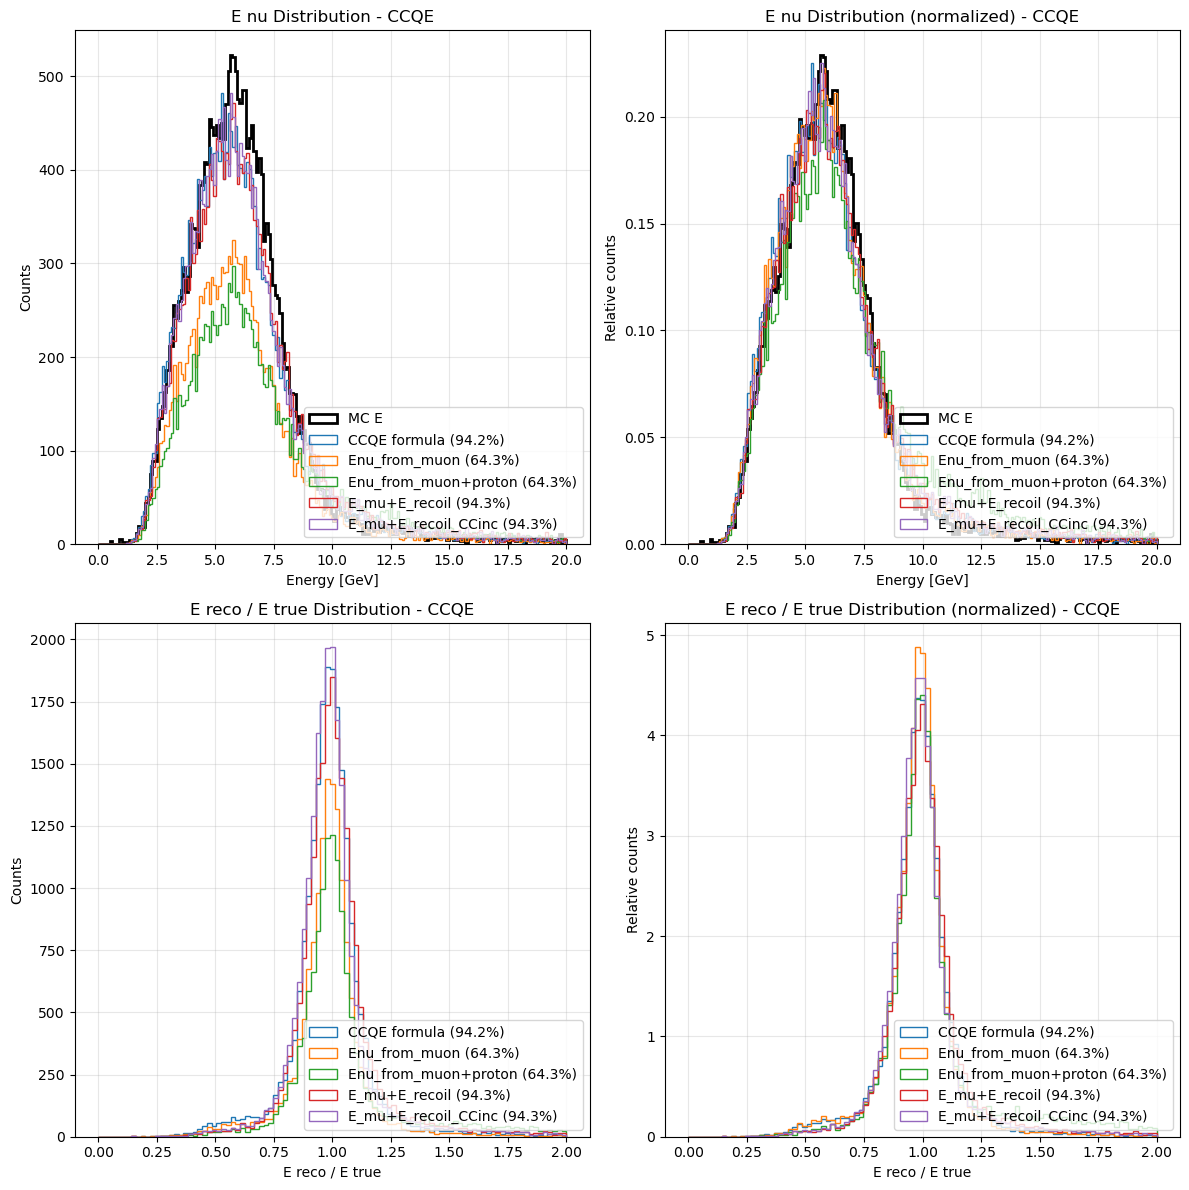

  Saved to out/Enu_reconstruction_CCQE.pdf
Creating energy plot for RES (40132 events)...


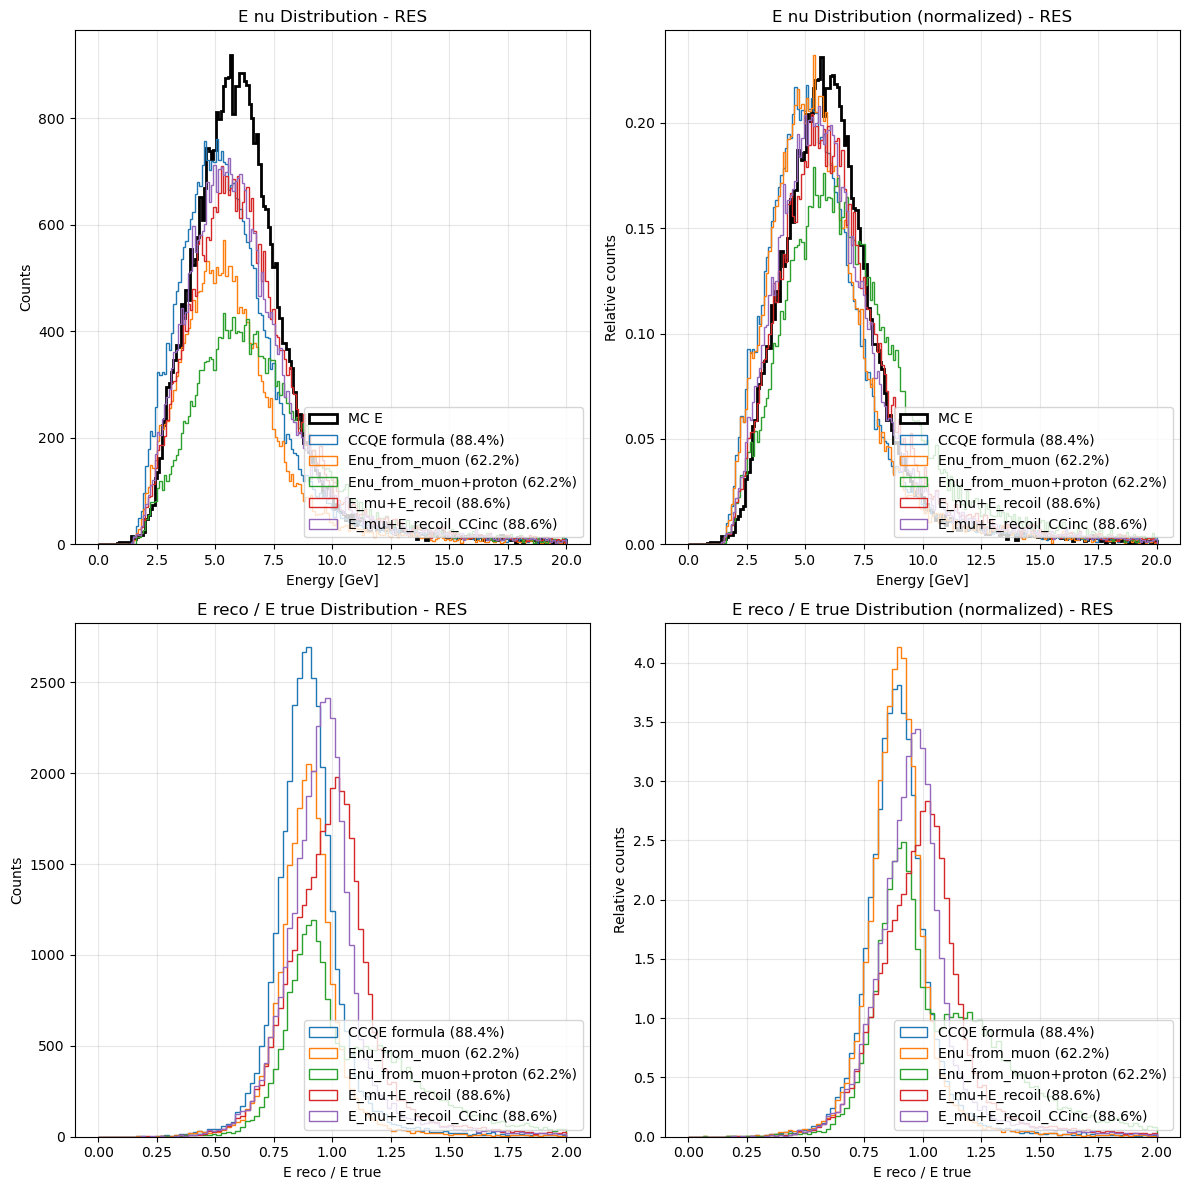

  Saved to out/Enu_reconstruction_RES.pdf
Creating energy plot for DIS (114574 events)...


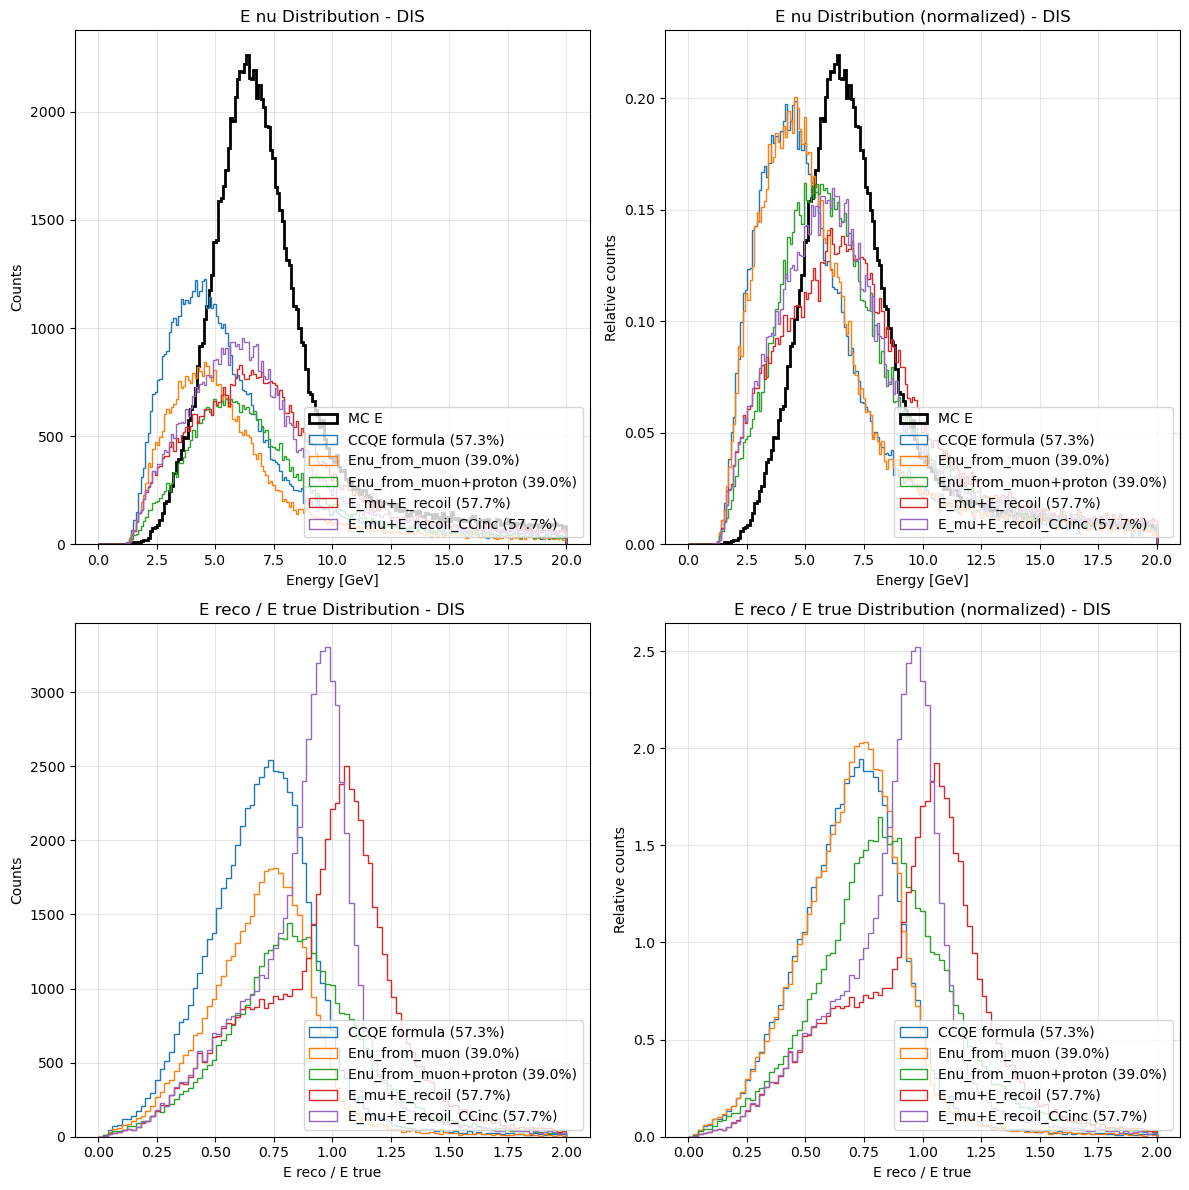

  Saved to out/Enu_reconstruction_DIS.pdf
Creating energy plot for 2p2h (6737 events)...


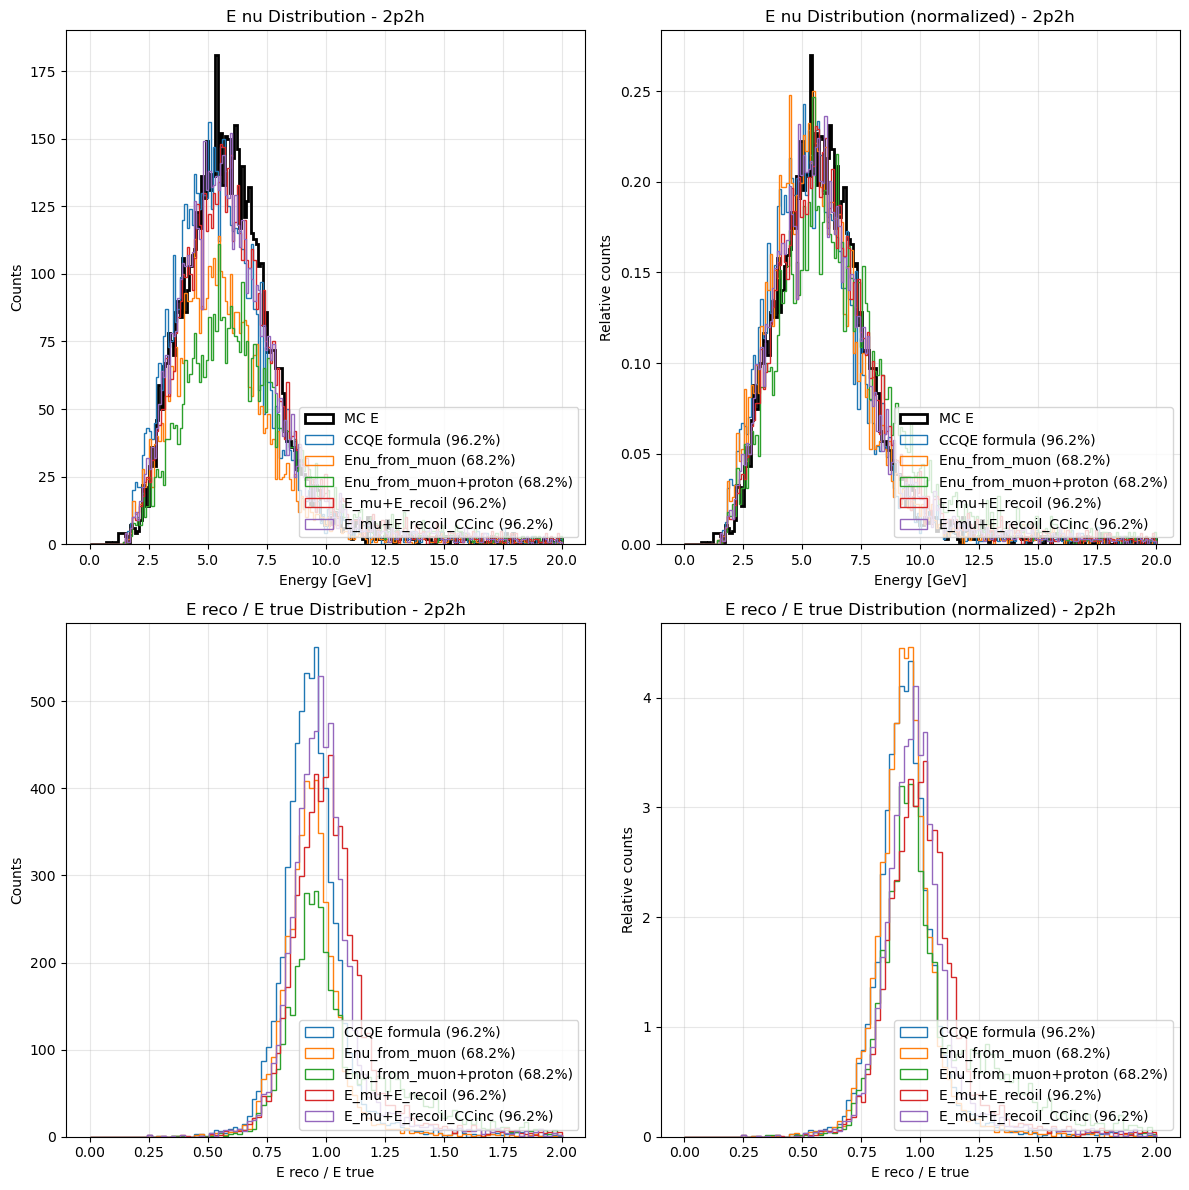

  Saved to out/Enu_reconstruction_2p2h.pdf
Creating energy plot for Coherent (1948 events)...


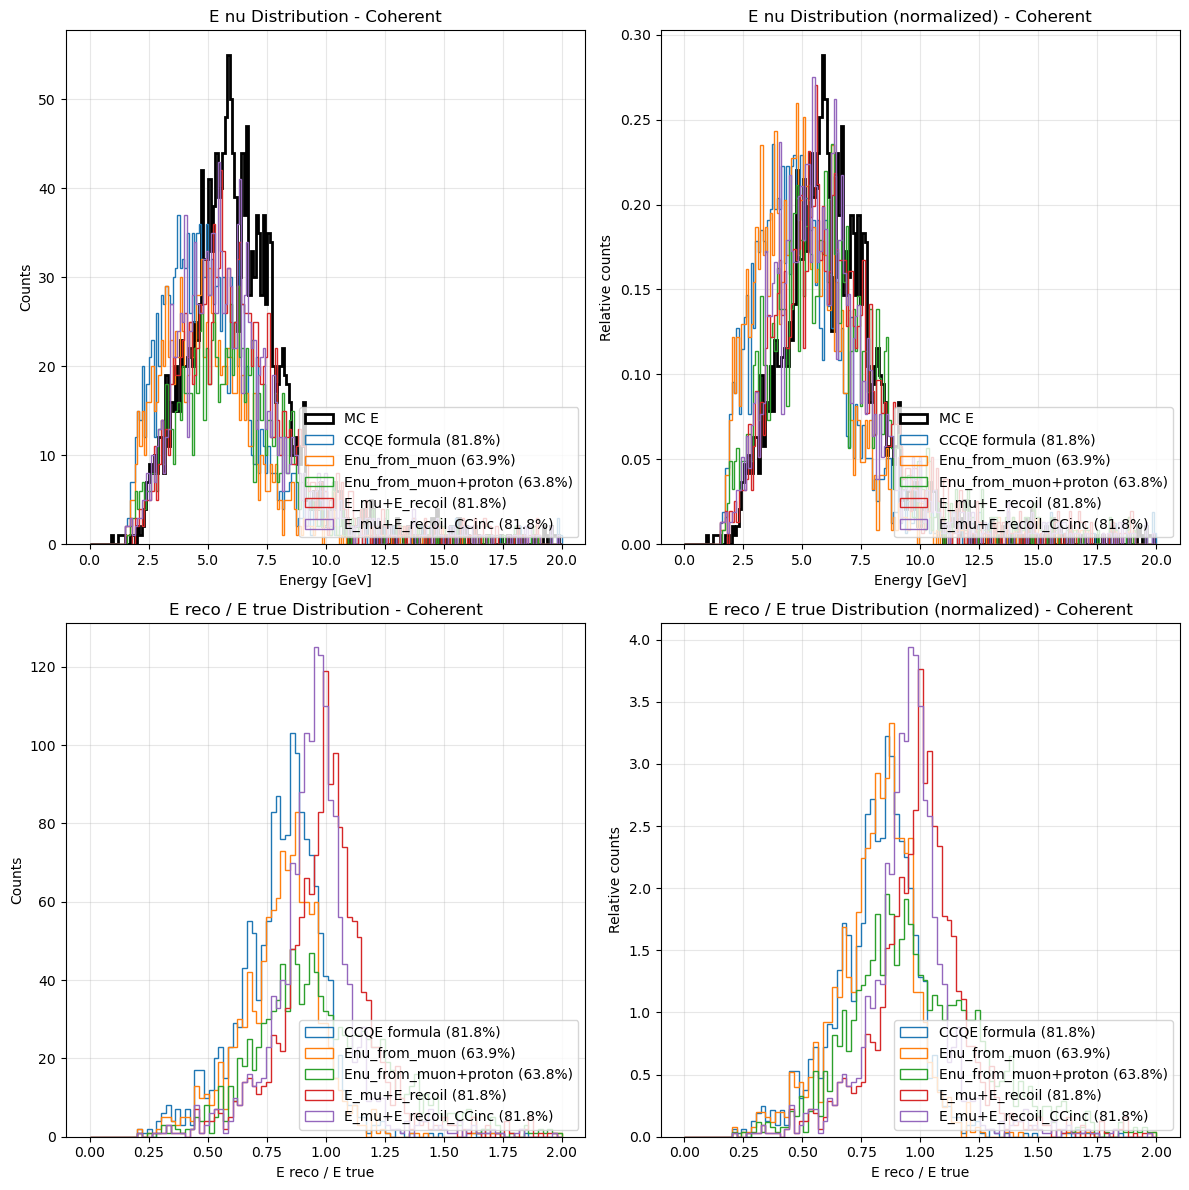

  Saved to out/Enu_reconstruction_Coherent.pdf
Creating energy plot for Other (17 events)...


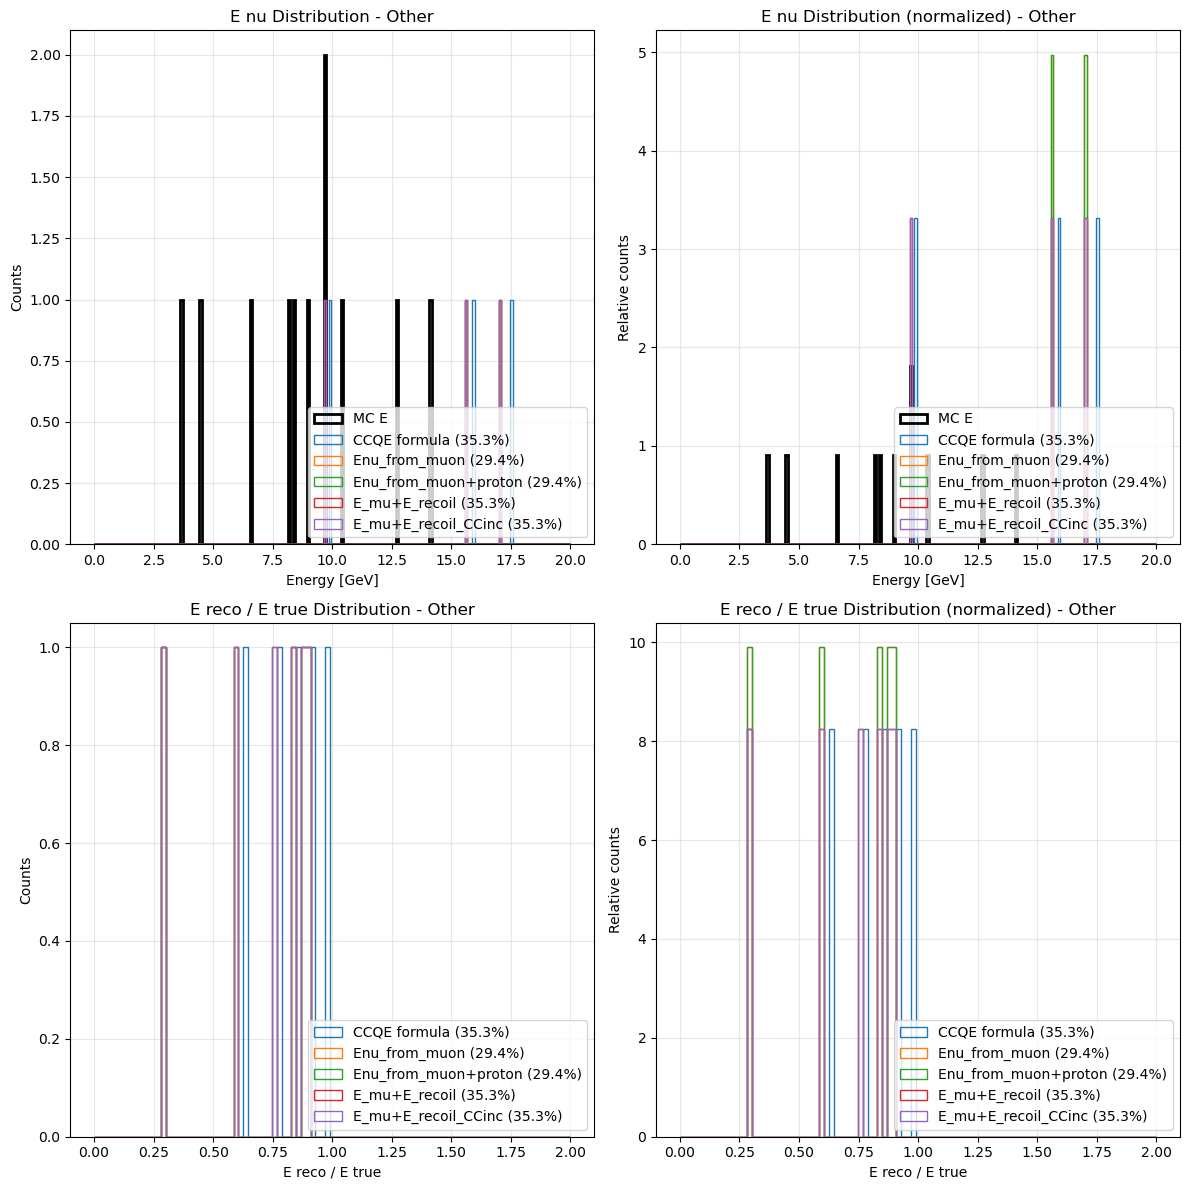

  Saved to out/Enu_reconstruction_Other.pdf


: 

In [ ]:
# Generate plots for each interaction type
for int_type_name, mask in masks_dict.items():
    if mask.sum() < 10:  # Skip if too few events
        print(f"Skipping {int_type_name} (only {mask.sum()} events)")
        continue
    
    print(f"Creating energy plot for {int_type_name} ({mask.sum()} events)...")
    fig = get_Enu_fig_by_inttype(E_nu_MC, results, int_type_name, mask)
    fig.savefig(f"out/Enu_reconstruction_{int_type_name}.pdf")
    plt.show()
    print(f"  Saved to out/Enu_reconstruction_{int_type_name}.pdf")

In [ ]:
# Print detailed statistics for each interaction type
print("=" * 80)
print("MULTIPLICITY STATISTICS BY INTERACTION TYPE")
print("=" * 80)

for int_type, mask in masks_dict.items():
    n_events = mask.sum()
    if n_events == 0:
        continue
    
    print(f"\n{int_type} ({n_events} events, {100*n_events/len(mask):.1f}%):")
    print("-" * 60)
    
    for coll_name, coll in collections_dict.items():
        mult = coll.n[mask]
        print(f"  {coll_name:15s}: mean={mult.mean():.2f}, std={mult.std():.2f}, "
              f"min={mult.min()}, max={mult.max()}, median={np.median(mult):.1f}")

MULTIPLICITY STATISTICS BY INTERACTION TYPE

CCQE (23031 events, 12.4%):
------------------------------------------------------------
  MC Particles   : mean=5.10, std=4.87, min=2, max=85, median=3.0
  Prongs         : mean=1.29, std=0.51, min=1, max=8, median=1.0
  Blobs          : mean=2.38, std=5.20, min=0, max=78, median=1.0
  Muons          : mean=0.94, std=0.23, min=0, max=1, median=1.0

RES (40132 events, 21.5%):
------------------------------------------------------------
  MC Particles   : mean=6.72, std=7.86, min=3, max=106, median=4.0
  Prongs         : mean=1.68, std=0.65, min=1, max=9, median=2.0
  Blobs          : mean=5.26, std=6.35, min=0, max=94, median=4.0
  Muons          : mean=0.89, std=0.32, min=0, max=1, median=1.0

DIS (114574 events, 61.5%):
------------------------------------------------------------
  MC Particles   : mean=9.56, std=12.73, min=3, max=189, median=6.0
  Prongs         : mean=1.89, std=0.85, min=1, max=12, median=2.0
  Blobs          : mean=17.6

: 

In [ ]:
mc_current = master_ana_dev["mc_current"].array().to_numpy()

: 

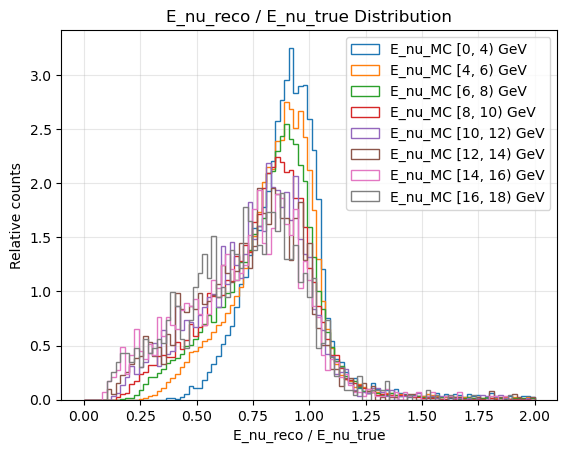

: 

In [ ]:
# Now, plot E_nu_reco / E_nu_true histograms for various energy bins.
bins_E = [0, 4, 6, 8, 10, 12, 14, 16, 18]
bins_E_reco_over_true = np.linspace(0, 2, 100)
fig, ax = plt.subplots()

for i in range(len(bins_E)-1):
    mask_E = (E_nu_MC/1000 >= bins_E[i]) & (E_nu_MC/1000 < bins_E[i+1])
    E_reco_over_true = results["Enu_from_muon"][mask_E & (mc_current==1)] / E_nu_MC[mask_E & (mc_current==1)]
    ax.hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=f"E_nu_MC [{bins_E[i]}, {bins_E[i+1]}) GeV", density=True)
    ax.legend()
    ax.set_xlabel("E_nu_reco / E_nu_true")
    ax.set_ylabel("Relative counts")
    ax.set_title("E_nu_reco / E_nu_true Distribution")
    ax.grid(True, alpha=0.3)


In [ ]:
gamma1 = master_ana_dev["gamma1_E"].array().to_numpy()

: 

In [ ]:
# sum up prong and blob energies per event
E_prong_per_event = np.zeros(len(prong.n))
E_blob_per_event = np.zeros(len(blob.n))
for i in range(len(prong.n)):
    E_prong_per_event[i] = np.sum(prong.data[prong.bounds[i]:prong.bounds[i+1]][:,3])
    E_blob_per_event[i] = np.sum(blob.data[blob.bounds[i]:blob.bounds[i+1]][:,5])



: 

In [ ]:
E_prong_blob_per_event = E_prong_per_event + E_blob_per_event
E_prong_blob_per_event

array([ 5224.29684448,  6441.44775391,  2679.05485916, ...,
        7994.89129639, 19493.66796875,  3828.53417969], shape=(186439,))

: 

In [ ]:
prong_pid = prong.data[:, -1]

: 

In [ ]:
prong_mass = prong.data[:, -3]

: 

In [ ]:
# Get masses of each unique prong_pid
unique_pids = np.unique(prong_pid)
pid_to_mass_list = {}
for pid in unique_pids:
    pid_to_mass_list[pid] = prong_mass[prong_pid == pid]



: 

In [ ]:
# print value counts of prong pids
val_counts = np.unique(prong.data[:, -1], return_counts=True)

: 

In [ ]:
# now make a nice printable table
print(f"{'PID':<5} {'Count':<10}")
print("-" * 20)
for pid, count in zip(val_counts[0], val_counts[1]):
    print(f"{pid:<5} {count:<10}")
# print value counts of blob pids
val_counts = np.unique(blob.data[:, -1], return_counts=True)



PID   Count     
--------------------
-999.0 13200     
0.0   17871     
3.0   131943    
8.0   92514     
13.0  70513     


: 

In [ ]:
np_gamma = master_ana_dev["gamma1_E"].array().to_numpy()

: 

In [ ]:
def event_display(event_idx, muons=None, photons=None, mc_part=None, blobs=None, prongs=None, 
                  figsize=(7, 7), title=None):
    """
    Display an event in the theta-phi plane with particle energies shown as marker sizes.
    
    Parameters:
    -----------
    event_idx : int
        Event index to display
    muons, photons, mc_part, blobs, prongs : DenseCollection, optional
        Collections of particles to display
    figsize : tuple
        Figure size
    title : str, optional
        Custom title for the plot
    """
    
    def compute_theta_phi_energy(px, py, pz, E):
        """Compute theta, phi, and energy from momentum components"""
        p = np.sqrt(px**2 + py**2 + pz**2)
        theta = np.arctan2(np.sqrt(px**2 + py**2), pz)  # angle from z-axis
        phi = np.arctan2(py, px)  # angle in x-y plane
        return theta, phi, E
    
    def get_column_slice(collection, key):
        """Get the column slice for a given key in the collection"""
        start_idx = 0
        for i, k in enumerate(collection.keys):
            if k == key:
                width = collection.column_widths[i]
                if width == 1:
                    return collection.data[:, start_idx]
                else:
                    return collection.data[:, start_idx:start_idx+width]
            start_idx += collection.column_widths[i]
        return None
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # PDG code to name mapping for common particles
    pdg_names = {
        22: 'γ', 211: 'π+', -211: 'π-', 111: 'π0',
        2212: 'p', -2212: 'p̄', 2112: 'n', -2112: 'n̄',
        13: 'μ-', -13: 'μ+', 11: 'e-', -11: 'e+',
        321: 'K+', -321: 'K-', 130: 'K0L', 310: 'K0S'
    }

    pdg_names_for_prong = {
        3: "prong_μ",
        8: "prong_p"
    }
    
    collections_data = []
    
    # Process muons
    if muons is not None and muons.n[event_idx] > 0:
        start, end = muons.bounds[event_idx], muons.bounds[event_idx + 1]
        muon_data = muons.data[start:end]
        
        # Get momentum components - check if using MasterAnaDev_muon or corrected_p
        if 'MasterAnaDev_muon_Px' in muons.keys:
            px = get_column_slice(muons, 'MasterAnaDev_muon_Px')[start:end]
            py = get_column_slice(muons, 'MasterAnaDev_muon_Py')[start:end]
            pz = get_column_slice(muons, 'MasterAnaDev_muon_Pz')[start:end]
            E = get_column_slice(muons, 'MasterAnaDev_muon_E')[start:end]
        else:
            # Compute from angles if available
            p = get_column_slice(muons, 'muon_corrected_p')[start:end, 0]
            theta_x = get_column_slice(muons, 'muon_thetaX')[start:end]
            theta_y = get_column_slice(muons, 'muon_thetaY')[start:end]
            px = p * np.sin(theta_x)
            py = p * np.sin(theta_y)
            pz = p * np.sqrt(1 - np.sin(theta_x)**2 - np.sin(theta_y)**2)
            E = get_column_slice(muons, 'MasterAnaDev_muon_E')[start:end]
        
        theta, phi, energy = compute_theta_phi_energy(px, py, pz, E)
        collections_data.append(('Muons', theta, phi, energy, 'blue', 'o', None))
    
    # Process photons
    if photons is not None and photons.n[event_idx] > 0:
        start, end = photons.bounds[event_idx], photons.bounds[event_idx + 1]
        px = get_column_slice(photons, 'gamma1_px')[start:end]
        py = get_column_slice(photons, 'gamma1_py')[start:end]
        pz = get_column_slice(photons, 'gamma1_pz')[start:end]
        E = get_column_slice(photons, 'gamma1_E')[start:end]
        
        theta, phi, energy = compute_theta_phi_energy(px, py, pz, E)
        collections_data.append(('Photons', theta, phi, energy, 'red', '*', None))
    
    # Process MC particles
    if mc_part is not None and mc_part.n[event_idx] > 0:
        start, end = mc_part.bounds[event_idx], mc_part.bounds[event_idx + 1]
        px = get_column_slice(mc_part, 'mc_FSPartPx')[start:end]
        py = get_column_slice(mc_part, 'mc_FSPartPy')[start:end]
        pz = get_column_slice(mc_part, 'mc_FSPartPz')[start:end]
        E = get_column_slice(mc_part, 'mc_FSPartE')[start:end]
        pdg = get_column_slice(mc_part, 'mc_FSPartPDG')[start:end].astype(int)
        
        theta, phi, energy = compute_theta_phi_energy(px, py, pz, E)
        collections_data.append(('MC Particles', theta, phi, energy, 'green', 's', pdg))
    
    # Process blobs
    if blobs is not None and blobs.n[event_idx] > 0:
        start, end = blobs.bounds[event_idx], blobs.bounds[event_idx + 1]
        x = get_column_slice(blobs, 'MasterAnaDev_BlobX')[start:end]
        y = get_column_slice(blobs, 'MasterAnaDev_BlobY')[start:end]
        z = get_column_slice(blobs, 'MasterAnaDev_BlobZ')[start:end]
        E = get_column_slice(blobs, 'MasterAnaDev_BlobTotalE')[start:end]
        
        # Treat position as direction
        theta, phi, energy = compute_theta_phi_energy(x, y, z, E)
        collections_data.append(('Blobs', theta, phi, energy, 'orange', 'D', None))
    
    # Process prongs
    if prongs is not None and prongs.n[event_idx] > 0:
        start, end = prongs.bounds[event_idx], prongs.bounds[event_idx + 1]
        #pos = get_column_slice(prongs, 'prong_part_pos')[start:end]
        pos = get_column_slice(prongs, 'prong_part_E')[start:end][:, :3]
        E = get_column_slice(prongs, 'prong_part_E')[start:end][:, -1]
        pid = get_column_slice(prongs, 'prong_part_pid')[start:end].astype(int)
        
        # Extract x, y, z from position (assuming it's 3D)
        if len(pos.shape) == 2 and pos.shape[1] >= 3:
            x, y, z = pos[:, 0], pos[:, 1], pos[:, 2]
            theta, phi, energy = compute_theta_phi_energy(x, y, z, E)
            collections_data.append(('Prongs', theta, phi, energy, 'purple', '^', pid))
    
    # Plot all collections
    for name, theta, phi, energy, color, marker, labels in collections_data:
        # Size proportional to energy (scale for visibility)
        sizes = (energy / np.max(energy) * 500) if len(energy) > 0 and np.max(energy) > 0 else 100
        scatter = ax.scatter(phi, theta, s=sizes, c=color, marker=marker, 
                           alpha=0.6, edgecolors='black', linewidths=0.5, label=name)
        
        # Add labels for particles with PID information
        if labels is not None:
            for i, (p, t, lbl) in enumerate(zip(phi, theta, labels)):
                if name == "Prongs":
                    label_text = pdg_names_for_prong.get(lbl, str(lbl))
                else:
                    label_text = pdg_names.get(lbl, str(lbl))
                ax.annotate(label_text, (p, t), fontsize=8, ha='center', va='center',
                          bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))
    
    ax.set_xlabel('φ (radians)', fontsize=12)
    ax.set_ylabel('θ (radians)', fontsize=12)
    ax.set_xlim(-np.pi, np.pi)
    #ax.set_ylim(0, np.pi)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    
    if title:
        ax.set_title(title, fontsize=14)
    else:
        ax.set_title(f'Event Display - Event {event_idx}', fontsize=14)
    
    fig.tight_layout()
    return fig

: 

In [ ]:
prong.keys, prong.column_widths

(['prong_part_pos',
  'prong_part_E',
  'prong_part_score',
  'prong_part_mass',
  'prong_part_charge',
  'prong_part_pid'],
 [4, 4, 1, 1, 1, 1])

: 

In [ ]:
prongs_p = prong.data[:, 4:8]
prong_E = prongs_p[:, -1]
prong_p = np.linalg.norm(prongs_p[:, :3], axis=1)
prongM = np.sqrt(prong_E ** 2 - prong_p**2)

/tmp/ipykernel_5763/804579506.py:4: RuntimeWarning: invalid value encountered in sqrt
  prongM = np.sqrt(prong_E ** 2 - prong_p**2)


: 

In [ ]:
human_readable_current = {
    1: "CC",
    2: "NC"
}
human_readable_intType = {
    1: "CCQE",
    2: "Resonance/Delta",
    3: "DIS",
    4: "Coherent scattering",
    8: "2p2h"
}

: 

In [ ]:
mc_current = master_ana_dev["mc_current"].array().to_numpy()
mc_intType = master_ana_dev["mc_intType"].array().to_numpy()

: 

In [ ]:
np.unique(mc_current[mc_intType == 1], return_counts=True)

(array([1, 2], dtype=int32), array([22976,    55]))

: 

In [ ]:
np.unique(mc_current[mc_intType == 2], return_counts=True)

(array([1, 2], dtype=int32), array([38607,  1525]))

: 

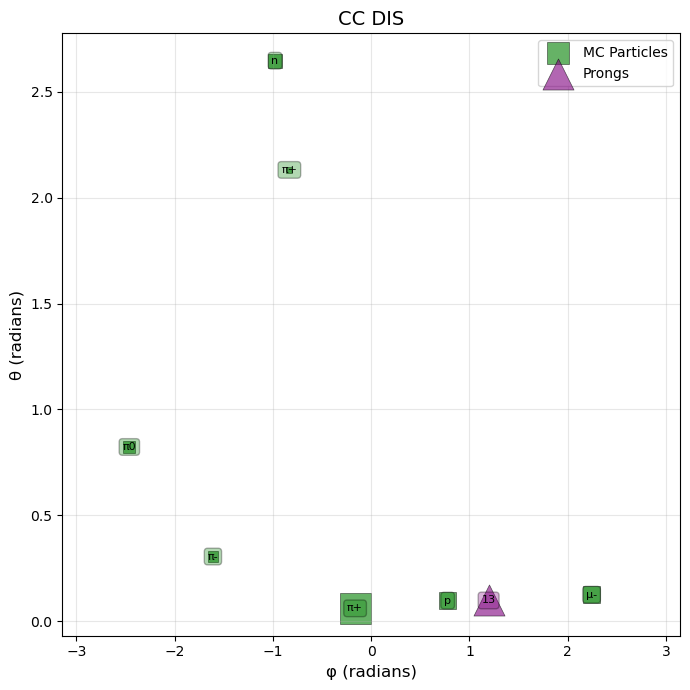

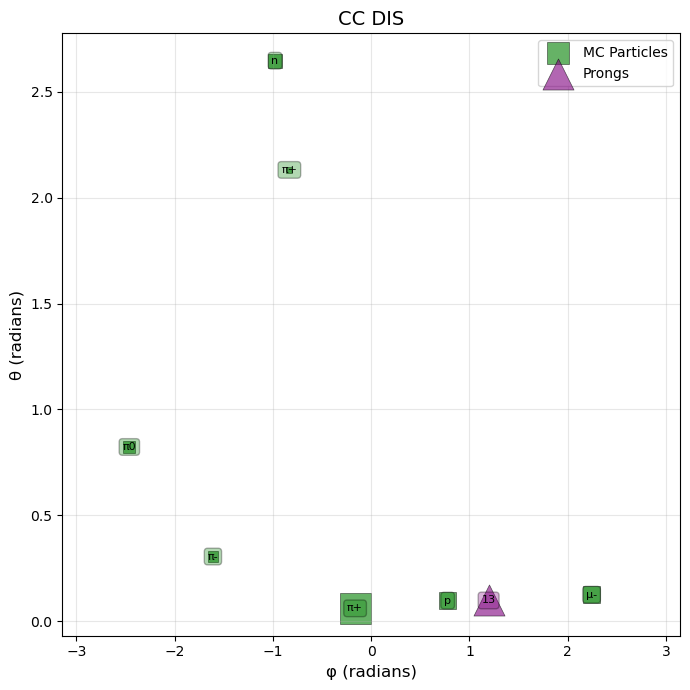

: 

In [ ]:
event_idx = 1617
event_display(event_idx, muons=muon, photons=photons, mc_part=mc_part, blobs=blob, prongs=prong, title=f"{human_readable_current[mc_current[event_idx]]} {human_readable_intType[mc_intType[event_idx]]}")

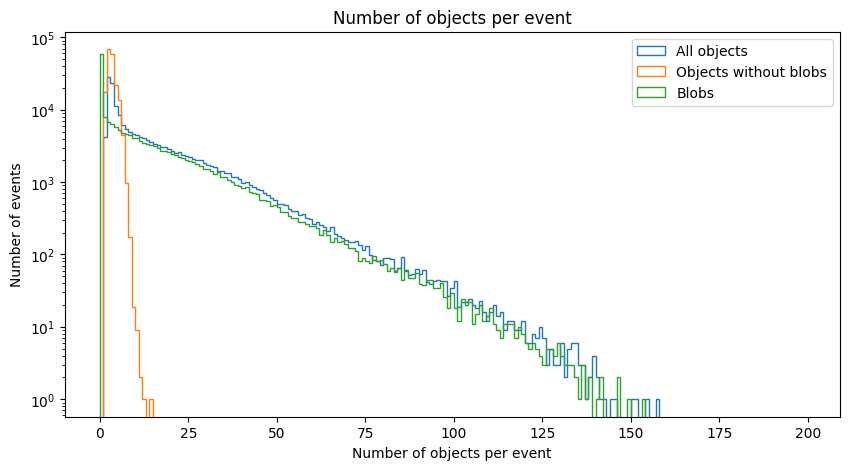

In [71]:
# sum the number of all objects per event - blobs, prongs, muons, photons
n_blobs = blob.n
n_prongs = prong.n
n_muons = muon.n
n_photons = photons.n
n_objects = n_blobs + n_prongs + n_muons + n_photons
n_objects_without_blobs = n_prongs + n_muons + n_photons
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(n_objects, bins=np.arange(0, 200, 1), histtype="step", label="All objects")
ax.hist(n_objects_without_blobs, bins=np.arange(0, 200, 1), histtype="step", label="Objects without blobs")
ax.hist(n_blobs, bins=np.arange(0, 200, 1), histtype="step", label="Blobs")
ax.set_xlabel("Number of objects per event")
ax.legend()
ax.set_ylabel("Number of events")
ax.set_title("Number of objects per event")
ax.set_yscale("log")
fig.show()


In [63]:
# if i cap at 50 objects, what is the fraction of events that are removed?
n_objects_50 = np.where(n_objects <= 100, 0, 1)
n_events_50 = np.sum(n_objects_50)
n_events = len(n_objects)
fraction_removed = (n_events - n_events_50) / n_events
print(f"Fraction of events that are kept : {fraction_removed:.2%}")

Fraction of events that are kept : 99.78%


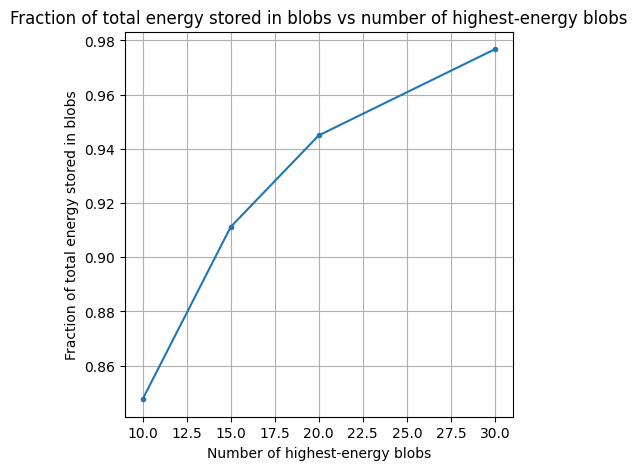

In [77]:
# Make a plot of % of total energy stored in blobs vs the number of highest-energy blobs that we take (and the rest, throw out, per event)
N_highest_energy_blobs = np.array([10, 15, 20, 30])
total_energy_in_blobs_per_event = 0
energy_stored_in_N_highest_energy_blobs_per_event = np.zeros(len(N_highest_energy_blobs))
for i in range(len(blob.n)-1):
    total_energy_in_blobs_per_event += np.sum(blob.data[blob.bounds[i]:blob.bounds[i+1]][:, 5])
    for j in range(len(N_highest_energy_blobs)):
        #energy_stored_in_N_highest_energy_blobs_per_event[j] += np.sum(blob.data[blob.bounds[i]:blob.bounds[i+1]][:, 5][-N_highest_energy_blobs[j]:])
        all_blob_energies = blob.data[blob.bounds[i]:blob.bounds[i+1]][:, 5]
        sorted_blob_energies = np.sort(all_blob_energies)[::-1]
        energy_stored_in_N_highest_energy_blobs_per_event[j] += np.sum(sorted_blob_energies[:N_highest_energy_blobs[j]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(N_highest_energy_blobs, energy_stored_in_N_highest_energy_blobs_per_event / total_energy_in_blobs_per_event, ".-")
ax.set_xlabel("Number of highest-energy blobs")
ax.set_ylabel("Fraction of total energy stored in blobs")
ax.set_title("Fraction of total energy stored in blobs vs number of highest-energy blobs")
ax.grid()
fig.show()

In [ ]:
# Go through the events and 

(2321442, 6)